**K. TUTORIAL LANGKAH DEMI LANGKAH**

K-1 — Persiapkan environment

persiapan lingkungan kerja untuk seluruh proses Praktikum 3, yaitu mengecek library seperti pandas, numpy, pyarrow, requests, sklearn, dan sqlalchemy, menghubungkan Google Drive, serta membuat folder lapisan_mentah, lapisan_terkurasi, dan folder penyimpanan hasil Praktikum 3.

K-1 juga membuat lineage, yaitu catatan asal-usul data yang nantinya digunakan untuk mengetahui sumber, waktu pengambilan, jumlah baris, dan keterangan dari setiap dataset.

In [30]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"

for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# --- Dipakai kembali dari Praktikum 1 / K-3 ---
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({
        "langkah": label,
        "detik": round(detik, 2),
        "delta_rss_mb": round(rss_mb() - m0, 1)
    })
    print(f"[{label}] {detik:.2f} s")
    return hasil

# --- Baru di Praktikum 3: catatan asal-usul data (lineage) ---
lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama,
        "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris,
        "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.54
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


K-2. Akuisisi 1 — Unduhan Berkala

dilakukan pengumpulan data utama berupa data perjalanan taksi Januari 2023 dalam format Parquet dan data zona taksi dalam format CSV. Fungsi unduh_aman() digunakan agar proses pengambilan data lebih aman karena memiliki cache, retry ketika gagal, exponential backoff, dan atomic write.

In [31]:
import requests
import pyarrow.parquet as pq

# Mengurangi penggunaan memori jika K-2 sebelumnya pernah dijalankan
if "trip" in globals():
    del trip
    gc.collect()


def cache_valid(path):
    """
    Memeriksa apakah berkas cache tersedia dan dapat dibaca.
    """

    if not os.path.exists(path):
        return False

    if os.path.getsize(path) == 0:
        return False

    try:
        if path.endswith(".csv"):
            pd.read_csv(path, nrows=2)

        elif path.endswith(".parquet"):
            pq.ParquetFile(path).metadata

        return True

    except Exception as error:
        print(
            "Cache tidak valid:",
            os.path.basename(path),
            f"({error})"
        )
        return False


def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """
    Mengunduh berkas dengan cache, retry,
    dan penulisan atomik.
    """

    # Memakai cache jika berkas tersedia dan dapat dibaca
    if cache_valid(tujuan):
        print("Cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"

    for i in range(percobaan):
        try:
            with requests.get(
                url,
                stream=True,
                timeout=60
            ) as respons:

                respons.raise_for_status()

                # Menyimpan data sedikit demi sedikit
                with open(sementara, "wb") as berkas:
                    for potongan in respons.iter_content(
                        chunk_size=1024 * 1024
                    ):
                        if potongan:
                            berkas.write(potongan)

                # Memastikan hasil unduhan tidak kosong
                if os.path.getsize(sementara) == 0:
                    raise IOError("Berkas hasil unduhan kosong")

                # Mengganti cache lama dengan berkas baru
                os.replace(sementara, tujuan)

                # Memastikan berkas baru dapat dibaca
                if not cache_valid(tujuan):
                    raise IOError(
                        "Berkas selesai diunduh, tetapi tidak dapat dibaca"
                    )

                print(
                    "Unduhan selesai:",
                    os.path.basename(tujuan)
                )

                return tujuan

        except Exception as error:
            # Menghapus berkas sementara jika proses gagal
            if os.path.exists(sementara):
                os.remove(sementara)

            jeda = jeda_awal * (2 ** i)

            print(
                f"Percobaan {i + 1} gagal ({error}); "
                f"menunggu {jeda} detik"
            )

            if i < percobaan - 1:
                time.sleep(jeda)

    raise RuntimeError(
        f"Gagal mengunduh setelah {percobaan} percobaan: {url}"
    )


# URL sumber resmi NYC TLC
URL_TRIP = (
    "https://d37ci6vzurychx.cloudfront.net/"
    "trip-data/yellow_tripdata_2023-01.parquet"
)

URL_ZONA = (
    "https://d37ci6vzurychx.cloudfront.net/"
    "misc/taxi_zone_lookup.csv"
)


# Lokasi penyimpanan data mentah
PATH_TRIP = os.path.join(
    DIR_MENTAH,
    "yellow_tripdata_2023-01.parquet"
)

PATH_ZONA = os.path.join(
    DIR_MENTAH,
    "taxi_zone_lookup.csv"
)


# Mengunduh dataset perjalanan dan tabel zona
ukur(
    "unduh trip",
    lambda: unduh_aman(URL_TRIP, PATH_TRIP)
)

ukur(
    "unduh zona",
    lambda: unduh_aman(URL_ZONA, PATH_ZONA)
)


# Menampilkan ukuran berkas
print("\nUkuran berkas:")

for path in (PATH_TRIP, PATH_ZONA):
    ukuran_byte = os.path.getsize(path)
    ukuran_mb = ukuran_byte / 1024**2

    print(
        f"{os.path.basename(path)} -> "
        f"{ukuran_mb:.4f} MB "
        f"({ukuran_byte:,} byte)"
    )


# Daftar kolom yang diperlukan
KOLOM = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount"
]


# Membaca dataset perjalanan
trip = ukur(
    "baca trip",
    lambda: pd.read_parquet(
        PATH_TRIP,
        columns=KOLOM
    )
)


# Membaca tabel zona
zona = pd.read_csv(PATH_ZONA)


# Menghindari duplikasi lineage jika sel dijalankan ulang
lineage[:] = [
    item for item in lineage
    if item["sumber"] not in ("trip", "zona")
]


# Mencatat asal-usul data
catat_sumber(
    "trip",
    URL_TRIP,
    len(trip),
    "Parquet bulanan NYC TLC"
)

catat_sumber(
    "zona",
    URL_ZONA,
    len(zona),
    "Tabel referensi zona NYC TLC"
)


# Menampilkan informasi dataset
print("\nInformasi dataset:")

print(
    f"Dataset trip : {trip.shape[0]:,} baris "
    f"x {trip.shape[1]} kolom"
)

print(
    f"Tabel zona  : {zona.shape[0]:,} baris "
    f"x {zona.shape[1]} kolom"
)

print("\nKolom dataset trip:")
print(trip.columns.tolist())

print("\nLima baris pertama tabel zona:")
display(zona.head())

Cache ditemukan: yellow_tripdata_2023-01.parquet
[unduh trip] 0.00 s
Cache ditemukan: taxi_zone_lookup.csv
[unduh zona] 0.00 s

Ukuran berkas:
yellow_tripdata_2023-01.parquet -> 45.4649 MB (47,673,370 byte)
taxi_zone_lookup.csv -> 0.0118 MB (12,331 byte)
[baca trip] 1.45 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris

Informasi dataset:
Dataset trip : 3,066,766 baris x 10 kolom
Tabel zona  : 265 baris x 4 kolom

Kolom dataset trip:
['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'tip_amount', 'total_amount']

Lima baris pertama tabel zona:


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


K-3. Akuisisi 2 — API JSON

dilakukan pengambilan data cuaca dari Open-Meteo API untuk periode Januari 2023. Data yang digunakan adalah temperatur dan curah hujan per jam, kemudian nama kolom diubah menjadi jam_mulai, suhu_c, dan hujan_mm agar lebih mudah digunakan dalam proses penggabungan dengan data perjalanan. Kode juga memiliki mekanisme retry apabila API memberikan status error tertentu dan melakukan validasi untuk memastikan respons API memiliki struktur hourly. Setelah berhasil, jumlah data cuaca dan sumbernya dicatat ke lineage.

In [32]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(
    tanggal_mulai,
    tanggal_selesai,
    latitude=40.7128,
    longitude=-74.0060,
    maksimum_percobaan=3
):
    parameter = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": tanggal_mulai,
        "end_date": tanggal_selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York"
    }

    for percobaan_ke in range(1, maksimum_percobaan + 1):
        try:
            respons = requests.get(
                API_CUACA,
                params=parameter,
                timeout=60
            )

            # Respons berhasil
            if respons.status_code == 200:
                data_json = respons.json()

                if "hourly" not in data_json:
                    raise ValueError(
                        "Bagian 'hourly' tidak ditemukan pada respons API."
                    )

                data_cuaca = pd.DataFrame(data_json["hourly"])

                kolom_wajib = {
                    "time",
                    "temperature_2m",
                    "precipitation"
                }

                kolom_hilang = kolom_wajib - set(data_cuaca.columns)

                if kolom_hilang:
                    raise ValueError(
                        f"Kolom cuaca tidak lengkap: {kolom_hilang}"
                    )

                return data_cuaca

            # Status sementara yang masih layak dicoba ulang
            if respons.status_code in (429, 500, 502, 503, 504):
                waktu_tunggu = 2 ** (percobaan_ke - 1)

                print(
                    f"Percobaan {percobaan_ke} gagal "
                    f"dengan status {respons.status_code}. "
                    f"Mencoba kembali dalam {waktu_tunggu} detik."
                )

                time.sleep(waktu_tunggu)
                continue

            # Memunculkan error untuk status selain yang ditangani
            respons.raise_for_status()

        except requests.RequestException as error:
            if percobaan_ke == maksimum_percobaan:
                raise RuntimeError(
                    "Data cuaca gagal diambil setelah "
                    f"{maksimum_percobaan} percobaan."
                ) from error

            waktu_tunggu = 2 ** (percobaan_ke - 1)

            print(
                f"Terjadi gangguan koneksi: {error}. "
                f"Mencoba kembali dalam {waktu_tunggu} detik."
            )

            time.sleep(waktu_tunggu)

    raise RuntimeError("API cuaca tidak memberikan respons yang valid.")


# Mengambil data cuaca Januari 2023
cuaca = ukur(
    "ambil cuaca",
    lambda: ambil_cuaca("2023-01-01", "2023-01-31")
)

# Mengubah kolom waktu menjadi datetime
cuaca["time"] = pd.to_datetime(
    cuaca["time"],
    errors="coerce"
)

if cuaca["time"].isna().any():
    raise ValueError(
        "Terdapat nilai waktu cuaca yang gagal dikonversi."
    )

# Mengganti nama kolom agar lebih ringkas
cuaca = cuaca.rename(
    columns={
        "time": "jam_mulai",
        "temperature_2m": "suhu_c",
        "precipitation": "hujan_mm"
    }
)

# Mencegah duplikasi catatan apabila cell dijalankan ulang
lineage[:] = [
    item for item in lineage
    if item["sumber"] != "cuaca"
]

# Mencatat asal-usul data
catat_sumber(
    nama="cuaca",
    asal=API_CUACA,
    jumlah_baris=len(cuaca),
    keterangan="Open-Meteo hourly archive untuk New York City"
)

# Menampilkan hasil pemeriksaan
print("\nInformasi data cuaca:")
print(f"Jumlah baris : {len(cuaca):,}")
print(f"Jumlah kolom : {cuaca.shape[1]}")
print(
    "Rentang waktu:",
    cuaca["jam_mulai"].min(),
    "s.d.",
    cuaca["jam_mulai"].max()
)

print("\nJumlah nilai kosong:")
print(cuaca.isna().sum())

print("\nLima baris pertama:")
display(cuaca.head())

[ambil cuaca] 0.08 s
[lineage] cuaca: 744 baris

Informasi data cuaca:
Jumlah baris : 744
Jumlah kolom : 3
Rentang waktu: 2023-01-01 00:00:00 s.d. 2023-01-31 23:00:00

Jumlah nilai kosong:
jam_mulai    0
suhu_c       0
hujan_mm     0
dtype: int64

Lima baris pertama:


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


K-4. Jalur Cadangan jika Internet Diblokir

disiapkan data cuaca sintetis sebagai cadangan apabila pengambilan data dari API pada K-3 gagal. Fungsi cuaca_sintetis() menghasilkan waktu per jam selama Januari 2023 serta nilai suhu dan curah hujan yang dibuat secara acak dengan seed=7, sehingga hasilnya dapat direproduksi.

In [33]:
def cuaca_sintetis(
    tanggal_mulai="2023-01-01",
    tanggal_selesai="2023-01-31",
    seed=7
):
    jam = pd.date_range(
        tanggal_mulai,
        pd.Timestamp(tanggal_selesai) + pd.Timedelta("23h"),
        freq="h"
    )
    rng = np.random.default_rng(seed)

    return pd.DataFrame({
        "jam_mulai": jam,
        "suhu_c": np.round(rng.normal(3, 5, len(jam)), 1),
        "hujan_mm": np.round(rng.gamma(0.4, 0.8, len(jam)), 2),
    })

print(
    "K-4 tidak digunakan karena K-3 berhasil "
    "mengambil data cuaca nyata."
)


K-4 tidak digunakan karena K-3 berhasil mengambil data cuaca nyata.


K-5. Akuisisi 3 — SQLite

dibuat database SQLite bernama operasional.db sebagai contoh sumber data dari database relasional. Dibuat tabel tarif_referensi yang berisi jenis pembayaran dan tabel trip_operasional yang berisi sebagian data perjalanan. Setelah itu dilakukan query SQL untuk menghitung jumlah perjalanan dan rata-rata total_amount berdasarkan payment_type. Data juga dibaca menggunakan chunksize=50_000 untuk menunjukkan bahwa data besar dapat diproses secara bertahap tanpa harus memasukkan seluruh data ke memori sekaligus.

In [34]:
from sqlalchemy import create_engine

# Menentukan lokasi basis data SQLite
PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")

# Membuat koneksi melalui SQLAlchemy
engine = create_engine(f"sqlite:///{PATH_DB}")


# Membuat tabel referensi metode pembayaran
tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": [
        "Kartu kredit",
        "Tunai",
        "Gratis",
        "Sengketa",
        "Tidak diketahui",
        "Perjalanan batal"
    ],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0]
})

tarif_referensi.to_sql(
    name="tarif_referensi",
    con=engine,
    if_exists="replace",
    index=False
)


# Mengambil 300.000 baris pertama sebagai data operasional
trip_operasional = trip.head(300_000)

# Menyimpan data ke SQLite secara bertahap
trip_operasional.to_sql(
    name="trip_operasional",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=50_000
)


# Memeriksa tabel yang berhasil dibuat
daftar_tabel = pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name
    """,
    engine
)

print("Tabel yang berhasil dibuat:")
print(daftar_tabel["name"].tolist())


# Melakukan agregasi menggunakan SQL
SQL_RINGKASAN = """
SELECT
    payment_type,
    COUNT(*) AS jumlah,
    AVG(total_amount) AS rata_total
FROM trip_operasional
WHERE total_amount > 0
GROUP BY payment_type
ORDER BY jumlah DESC
"""

ringkas_db = pd.read_sql(
    SQL_RINGKASAN,
    engine
)

print("\nRingkasan berdasarkan payment_type:")
display(ringkas_db)


# Membaca tabel secara bertahap tanpa memuat semuanya sekaligus
total_baris = 0
jumlah_bagian = 0

for bagian in pd.read_sql(
    "SELECT trip_distance FROM trip_operasional",
    engine,
    chunksize=50_000
):
    jumlah_bagian += 1
    total_baris += len(bagian)

    print(
        f"Bagian {jumlah_bagian}: "
        f"{len(bagian):,} baris"
    )

print(
    f"\nTotal dibaca bertahap: "
    f"{total_baris:,} baris dalam "
    f"{jumlah_bagian} bagian"
)


# Membaca kembali tabel referensi dari SQLite
tarif_referensi = pd.read_sql(
    "SELECT * FROM tarif_referensi",
    engine
)

print("\nIsi tabel referensi pembayaran:")
display(tarif_referensi)


# Menghindari duplikasi lineage jika cell dijalankan ulang
lineage[:] = [
    item for item in lineage
    if item["sumber"] != "tarif_referensi"
]

catat_sumber(
    nama="tarif_referensi",
    asal=PATH_DB,
    jumlah_baris=len(tarif_referensi),
    keterangan="Tabel dimensi dari basis data operasional"
)

print("\nLokasi basis data:", PATH_DB)
print("K-5 selesai.")

Tabel yang berhasil dibuat:
['tarif_referensi', 'trip_operasional']

Ringkasan berdasarkan payment_type:


,payment_type,jumlah,rata_total
0,1,226967,31.339172
1,2,66504,25.218836
2,4,2082,26.611114
3,3,1553,22.089691


Bagian 1: 50,000 baris
Bagian 2: 50,000 baris
Bagian 3: 50,000 baris
Bagian 4: 50,000 baris
Bagian 5: 50,000 baris
Bagian 6: 50,000 baris

Total dibaca bertahap: 300,000 baris dalam 6 bagian

Isi tabel referensi pembayaran:


,payment_type,nama_pembayaran,kena_biaya_admin
0,1,Kartu kredit,1
1,2,Tunai,0
2,3,Gratis,0
3,4,Sengketa,0
4,5,Tidak diketahui,0
5,6,Perjalanan batal,0


[lineage] tarif_referensi: 6 baris

Lokasi basis data: /content/lapisan_mentah/operasional.db
K-5 selesai.


K-6 — Profil dan Validasi Kualitas Data

dilakukan pemeriksaan kualitas data perjalanan dengan menghitung durasi_menit, kemudian membuat fungsi profil_kolom() untuk mengetahui tipe data, persentase nilai hilang, jumlah nilai unik, dan contoh nilai setiap kolom.

In [35]:
# Menghitung durasi perjalanan dalam satuan menit
trip["durasi_menit"] = (
    (
        trip["tpep_dropoff_datetime"]
        - trip["tpep_pickup_datetime"]
    )
    .dt.total_seconds()
    / 60
)


# Membuat profil dasar untuk setiap kolom
def profil_kolom(df):
    baris = []

    for kolom in df.columns:
        seri = df[kolom]

        contoh = (
            seri.dropna().iloc[0]
            if seri.notna().any()
            else None
        )

        baris.append({
            "kolom": kolom,
            "tipe": str(seri.dtype),
            "persen_hilang": round(
                100 * seri.isna().mean(),
                3
            ),
            "nilai_unik": seri.nunique(
                dropna=True
            ),
            "contoh": contoh
        })

    return pd.DataFrame(baris)


profil = profil_kolom(trip)

print("Profil setiap kolom:")
display(profil)


# Menentukan rentang waktu data
AWAL = pd.Timestamp("2023-01-01")
AKHIR = pd.Timestamp("2023-02-01")

# Mengambil seluruh LocationID yang terdaftar
zona_sah = set(zona["LocationID"])


# Menentukan aturan pemeriksaan kualitas
aturan = {
    "kelengkapan: passenger_count ada":
        trip["passenger_count"].notna(),

    "keunikan: baris tidak duplikat":
        ~trip.duplicated(),

    "validitas: jarak 0,01-100 mil":
        trip["trip_distance"].between(
            0.01,
            100
        ),

    "validitas: total_amount > 0":
        trip["total_amount"] > 0,

    "validitas: PULocationID dikenal":
        trip["PULocationID"].isin(zona_sah),

    "konsistensi: durasi 1-180 menit":
        trip["durasi_menit"].between(
            1,
            180
        ),

    "konsistensi: total >= fare":
        trip["total_amount"]
        >= trip["fare_amount"],

    "ketepatan waktu: dalam Jan 2023":
        trip["tpep_pickup_datetime"].between(
            AWAL,
            AKHIR
        )
}


# Membuat laporan jumlah data yang lulus dan gagal
laporan = pd.DataFrame([
    {
        "aturan": nama,
        "lulus": int(mask.sum()),
        "gagal": int((~mask).sum()),
        "persen_gagal": round(
            100 * (~mask).mean(),
            3
        )
    }
    for nama, mask in aturan.items()
]).sort_values(
    "persen_gagal",
    ascending=False
).reset_index(drop=True)


print("\nLaporan kualitas data:")
display(laporan)


# Pemeriksaan jumlah baris
print(
    "\nJumlah baris yang diperiksa:",
    f"{len(trip):,}"
)

print(
    "Jumlah aturan kualitas:",
    len(aturan)
)

print(
    "Aturan dengan persentase gagal tertinggi:",
    laporan.iloc[0]["aturan"]
)

print(
    "Persentase gagal tertinggi:",
    f"{laporan.iloc[0]['persen_gagal']:.3f}%"
)

print("\nK-6 selesai.")

Profil setiap kolom:


,kolom,tipe,persen_hilang,nilai_unik,contoh
0,tpep_pickup_datetime,datetime64[us],0.000,1610975,2023-01-01 00:32:10
1,tpep_dropoff_datetime,datetime64[us],0.000,1611319,2023-01-01 00:40:36
2,passenger_count,float64,2.339,10,1.0
3,trip_distance,float64,0.000,4387,0.97
4,PULocationID,int64,0.000,257,161
5,DOLocationID,int64,0.000,261,141
6,payment_type,int64,0.000,5,2
7,fare_amount,float64,0.000,6873,9.3
8,tip_amount,float64,0.000,4036,0.0
9,total_amount,float64,0.000,15871,14.3



Laporan kualitas data:


,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
1,"validitas: jarak 0,01-100 mil",3020816,45950,1.498
2,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
4,konsistensi: total >= fare,3041743,25023,0.816
5,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
6,keunikan: baris tidak duplikat,3066766,0,0.000
7,validitas: PULocationID dikenal,3066766,0,0.000



Jumlah baris yang diperiksa: 3,066,766
Jumlah aturan kualitas: 8
Aturan dengan persentase gagal tertinggi: kelengkapan: passenger_count ada
Persentase gagal tertinggi: 2.339%

K-6 selesai.


K-7 — Menangani Missing Value dan Duplikat

Pada K-7 dilakukan penanganan nilai kosong pada passenger_count dengan membandingkan beberapa strategi, yaitu membuang data kosong, mengisi dengan median keseluruhan, mengisi dengan modus, dan mengisi menggunakan median berdasarkan jam perjalanan.

In [36]:
KOL = "passenger_count"

# Menyimpan data asli sebelum dilakukan imputasi
asli = trip[KOL].copy()

print(
    "Persentase nilai hilang:",
    round(100 * asli.isna().mean(), 3),
    "%"
)

print(
    "Jumlah nilai hilang:",
    f"{asli.isna().sum():,}"
)


# Mengambil jam penjemputan
trip["jam"] = (
    trip["tpep_pickup_datetime"]
    .dt.hour
)

# Menghitung median passenger_count pada setiap jam
median_per_jam = (
    trip.groupby("jam")[KOL]
    .transform("median")
)


# Membandingkan empat strategi
strategi = {
    "1_dibuang":
        asli.dropna(),

    "2_isi_median":
        asli.fillna(asli.median()),

    "3_isi_modus":
        asli.fillna(asli.mode().iloc[0]),

    "4_median_perjam":
        asli.fillna(median_per_jam)
}


banding = pd.DataFrame([
    {
        "strategi": nama,
        "n": len(seri),
        "mean": round(seri.mean(), 4),
        "median": seri.median(),
        "std": round(seri.std(), 4),
        "nilai_hilang": int(seri.isna().sum())
    }
    for nama, seri in strategi.items()
])

print("\nPerbandingan strategi nilai hilang:")
display(banding)


# Membuat indikator nilai yang awalnya hilang
trip[KOL + "_hilang"] = (
    trip[KOL]
    .isna()
    .astype("int8")
)

# Strategi terpilih: median berdasarkan jam
trip[KOL] = trip[KOL].fillna(
    median_per_jam
)

# Jaring pengaman dengan median keseluruhan
trip[KOL] = trip[KOL].fillna(
    trip[KOL].median()
)

print(
    "\nNilai hilang setelah imputasi:",
    f"{trip[KOL].isna().sum():,}"
)

print(
    "Jumlah baris yang diberi nilai imputasi:",
    f"{trip[KOL + '_hilang'].sum():,}"
)


# Memeriksa duplikat penuh
dup_penuh = int(
    trip.duplicated().sum()
)

# Menentukan kunci perjalanan
KUNCI = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "total_amount"
]

# Memeriksa duplikat berdasarkan kunci
dup_kunci = int(
    trip.duplicated(
        subset=KUNCI
    ).sum()
)

print(
    "\nDuplikat penuh:",
    f"{dup_penuh:,}"
)

print(
    "Duplikat berdasarkan kunci:",
    f"{dup_kunci:,}"
)


# Menampilkan contoh jika ditemukan duplikat kunci
if dup_kunci > 0:
    contoh_duplikat = (
        trip.loc[
            trip.duplicated(
                subset=KUNCI,
                keep=False
            ),
            KUNCI
        ]
        .sort_values(KUNCI)
        .head(10)
    )

    print("\nContoh data dengan kunci yang sama:")
    display(contoh_duplikat)


# Menghapus pengulangan berdasarkan kunci
sebelum = len(trip)

trip = (
    trip.drop_duplicates(
        subset=KUNCI,
        keep="first"
    )
    .reset_index(drop=True)
)

sesudah = len(trip)
jumlah_dihapus = sebelum - sesudah

print(
    "\nJumlah baris:",
    f"{sebelum:,}",
    "->",
    f"{sesudah:,}"
)

print(
    "Baris yang dihapus:",
    f"{jumlah_dihapus:,}"
)

print(
    "Persentase baris yang dihapus:",
    f"{100 * jumlah_dihapus / sebelum:.4f}%"
)

print("\nK-7 selesai.")

Persentase nilai hilang: 2.339 %
Jumlah nilai hilang: 71,743

Perbandingan strategi nilai hilang:


,strategi,n,mean,median,std,nilai_hilang
0,1_dibuang,2995023,1.3625,1.0,0.8961,0
1,2_isi_median,3066766,1.3541,1.0,0.8873,0
2,3_isi_modus,3066766,1.3541,1.0,0.8873,0
3,4_median_perjam,3066766,1.3541,1.0,0.8873,0



Nilai hilang setelah imputasi: 0
Jumlah baris yang diberi nilai imputasi: 71,743

Duplikat penuh: 0
Duplikat berdasarkan kunci: 1

Contoh data dengan kunci yang sama:


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,total_amount
1341866,2023-01-15 11:03:50,2023-01-15 11:09:11,230,246,14.28
1343305,2023-01-15 11:03:50,2023-01-15 11:09:11,230,246,14.28



Jumlah baris: 3,066,766 -> 3,066,765
Baris yang dihapus: 1
Persentase baris yang dihapus: 0.0000%

K-7 selesai.


K-8 — Outlier dan Integrasi Data

Pada K-8 dilakukan pemeriksaan outlier menggunakan metode IQR dan Z-score, terutama pada trip_distance, durasi_menit, dan total_amount.

In [37]:
def batas_iqr(seri, k=1.5):
    q1, q3 = seri.quantile([0.25, 0.75])
    iqr = q3 - q1

    batas_bawah = q1 - k * iqr
    batas_atas = q3 + k * iqr

    return batas_bawah, batas_atas


# Membuat ringkasan outlier
def ringkas_outlier(df, daftar_kolom):
    hasil = []

    for kolom in daftar_kolom:
        seri = df[kolom].dropna()

        batas_bawah, batas_atas = batas_iqr(seri)

        z_score = (
            (seri - seri.mean())
            / seri.std()
        )

        hasil.append({
            "kolom": kolom,
            "batas_bawah": round(batas_bawah, 2),
            "batas_atas": round(batas_atas, 2),
            "outlier_iqr": int(
                (
                    (seri < batas_bawah)
                    | (seri > batas_atas)
                ).sum()
            ),
            "outlier_z3": int(
                (z_score.abs() > 3).sum()
            ),
            "p99": round(
                seri.quantile(0.99),
                2
            )
        })

    return pd.DataFrame(hasil)


ringkasan_outlier = ringkas_outlier(
    trip,
    [
        "trip_distance",
        "durasi_menit",
        "total_amount"
    ]
)

print("Ringkasan outlier:")
display(ringkasan_outlier)


# Menentukan baris yang layak digunakan
layak = (
    trip["trip_distance"].between(0.01, 100)
    & trip["durasi_menit"].between(1, 180)
    & (trip["total_amount"] > 0)
)

jumlah_sebelum = len(trip)

bersih = trip.loc[layak].copy()

jumlah_sesudah = len(bersih)
jumlah_dibuang = jumlah_sebelum - jumlah_sesudah
persen_dibuang = (
    100 * jumlah_dibuang / jumlah_sebelum
)

print("\nHasil penyaringan:")
print(
    f"{jumlah_sebelum:,} -> "
    f"{jumlah_sesudah:,} baris"
)
print(
    "Baris yang dibuang:",
    f"{jumlah_dibuang:,}"
)
print(
    "Persentase dibuang:",
    f"{persen_dibuang:.2f}%"
)


# Menandai tarif ekstrem tanpa menghapus baris
batas_bawah_tarif, batas_atas_tarif = batas_iqr(
    bersih["total_amount"]
)

bersih["tarif_ekstrem"] = (
    bersih["total_amount"]
    > batas_atas_tarif
).astype("int8")

print(
    "\nBatas atas tarif berdasarkan IQR:",
    round(batas_atas_tarif, 2)
)

print(
    "Jumlah tarif ekstrem:",
    f"{bersih['tarif_ekstrem'].sum():,}"
)


# Membatasi nilai ekstrem hanya pada kolom turunan
batas_atas_jarak = (
    bersih["trip_distance"]
    .quantile(0.995)
)

bersih["trip_distance_capped"] = (
    bersih["trip_distance"]
    .clip(upper=batas_atas_jarak)
)

print(
    "Batas persentil 99,5% untuk jarak:",
    round(batas_atas_jarak, 2)
)

print(
    "Jumlah jarak yang dibatasi:",
    f"{(bersih['trip_distance'] > batas_atas_jarak).sum():,}"
)


# JOIN 1: TABEL ZONA

kunci_zona_unik = zona["LocationID"].is_unique

print(
    "\nKunci LocationID tabel zona unik?",
    kunci_zona_unik
)

if not kunci_zona_unik:
    raise ValueError(
        "LocationID pada tabel zona tidak unik."
    )

jumlah_awal_join = len(bersih)

bersih = bersih.merge(
    zona[
        [
            "LocationID",
            "Borough",
            "Zone"
        ]
    ].rename(
        columns={
            "Borough": "borough_naik",
            "Zone": "zona_naik"
        }
    ),
    left_on="PULocationID",
    right_on="LocationID",
    how="left",
    validate="many_to_one"
)

bersih = bersih.drop(
    columns="LocationID"
)

print(
    "Join zona:",
    f"{jumlah_awal_join:,} -> "
    f"{len(bersih):,} baris"
)

print(
    "Zona tidak dikenal:",
    f"{bersih['zona_naik'].isna().sum():,}"
)


# JOIN 2: REFERENSI PEMBAYARAN


kunci_pembayaran_unik = (
    tarif_referensi["payment_type"]
    .is_unique
)

print(
    "\nKunci payment_type unik?",
    kunci_pembayaran_unik
)

if not kunci_pembayaran_unik:
    raise ValueError(
        "payment_type pada tabel referensi tidak unik."
    )

jumlah_awal_join = len(bersih)

bersih = bersih.merge(
    tarif_referensi[
        [
            "payment_type",
            "nama_pembayaran"
        ]
    ],
    on="payment_type",
    how="left",
    validate="many_to_one"
)

print(
    "Join pembayaran:",
    f"{jumlah_awal_join:,} -> "
    f"{len(bersih):,} baris"
)

print(
    "Pembayaran tidak dikenal:",
    f"{bersih['nama_pembayaran'].isna().sum():,}"
)



# JOIN 3: DATA CUACA BERDASARKAN JAM


bersih["jam_mulai"] = (
    bersih["tpep_pickup_datetime"]
    .dt.floor("h")
)

kunci_cuaca_unik = (
    cuaca["jam_mulai"]
    .is_unique
)

print(
    "\nKunci jam pada data cuaca unik?",
    kunci_cuaca_unik
)

if not kunci_cuaca_unik:
    raise ValueError(
        "Kolom jam_mulai pada data cuaca tidak unik."
    )

jumlah_awal_join = len(bersih)

bersih = bersih.merge(
    cuaca,
    on="jam_mulai",
    how="left",
    validate="many_to_one"
)

print(
    "Join cuaca:",
    f"{jumlah_awal_join:,} -> "
    f"{len(bersih):,} baris"
)

print(
    "Baris tanpa data cuaca:",
    f"{bersih['suhu_c'].isna().sum():,}"
)


# Menampilkan contoh hasil penggabungan
kolom_tampilan = [
    "tpep_pickup_datetime",
    "trip_distance",
    "durasi_menit",
    "total_amount",
    "zona_naik",
    "borough_naik",
    "nama_pembayaran",
    "suhu_c",
    "hujan_mm"
]

print("\nContoh hasil penggabungan:")
display(
    bersih[kolom_tampilan].head()
)

print(
    "\nUkuran data bersih:",
    f"{bersih.shape[0]:,} baris x "
    f"{bersih.shape[1]} kolom"
)

print("\nK-8 selesai.")

Ringkasan outlier:


,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,trip_distance,-2.35,6.74,390244,67,20.06
1,durasi_menit,-9.66,35.08,170615,3175,57.25
2,total_amount,-4.55,48.65,371616,87248,101.94



Hasil penyaringan:
3,066,765 -> 2,986,910 baris
Baris yang dibuang: 79,855
Persentase dibuang: 2.60%

Batas atas tarif berdasarkan IQR: 48.35
Jumlah tarif ekstrem: 336,253
Batas persentil 99,5% untuk jarak: 21.52
Jumlah jarak yang dibatasi: 14,885

Kunci LocationID tabel zona unik? True
Join zona: 2,986,910 -> 2,986,910 baris
Zona tidak dikenal: 37,609

Kunci payment_type unik? True
Join pembayaran: 2,986,910 -> 2,986,910 baris
Pembayaran tidak dikenal: 64,106

Kunci jam pada data cuaca unik? True
Join cuaca: 2,986,910 -> 2,986,910 baris
Baris tanpa data cuaca: 37

Contoh hasil penggabungan:


,tpep_pickup_datetime,trip_distance,durasi_menit,total_amount,zona_naik,borough_naik,nama_pembayaran,suhu_c,hujan_mm
0,2023-01-01 00:32:10,0.97,8.433333,14.30,Midtown Center,Manhattan,Tunai,10.9,1.0
1,2023-01-01 00:55:08,1.10,6.316667,16.90,Central Park,Manhattan,Kartu kredit,10.9,1.0
2,2023-01-01 00:25:04,2.51,12.750000,34.90,Clinton East,Manhattan,Kartu kredit,10.9,1.0
3,2023-01-01 00:03:48,1.90,9.616667,20.85,LaGuardia Airport,Queens,Kartu kredit,10.9,1.0
4,2023-01-01 00:10:29,1.43,10.833333,19.68,Gramercy,Manhattan,Kartu kredit,10.9,1.0



Ukuran data bersih: 2,986,910 baris x 21 kolom

K-8 selesai.


K-9 — Feature Engineering dan Scaling

dibuat beberapa fitur baru yang dapat digunakan untuk analisis atau machine learning, yaitu hari_minggu, akhir_pekan, kecepatan_mph, tarif_per_mil, dan hujan. Kemudian data numerik seperti jarak perjalanan, durasi, dan suhu diproses menggunakan StandardScaler, sedangkan data kategorikal seperti jenis pembayaran dan borough diubah menjadi bentuk numerik menggunakan OneHotEncoder.

In [38]:
bersih["hari_minggu"] = (
    bersih["tpep_pickup_datetime"].dt.dayofweek
)

bersih["akhir_pekan"] = (
    bersih["hari_minggu"] >= 5
).astype("int8")

bersih["kecepatan_mph"] = (
    bersih["trip_distance"]
    / (bersih["durasi_menit"] / 60)
).round(2)

bersih["tarif_per_mil"] = (
    bersih["total_amount"]
    / bersih["trip_distance"]
).round(3)

bersih["hujan"] = (
    bersih["hujan_mm"].fillna(0) > 0.1
).astype("int8")


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder


FITUR_NUM = [
    "trip_distance_capped",
    "durasi_menit",
    "suhu_c"
]

FITUR_KAT = [
    "nama_pembayaran",
    "borough_naik"
]


contoh = (
    bersih
    .dropna(subset=FITUR_NUM + FITUR_KAT)
    .sample(
        n=min(200_000, len(bersih)),
        random_state=42
    )
)


latih, uji = train_test_split(
    contoh,
    test_size=0.2,
    random_state=42
)


skala = StandardScaler().fit(
    latih[FITUR_NUM]
)

latih_num = skala.transform(
    latih[FITUR_NUM]
)

uji_num = skala.transform(
    uji[FITUR_NUM]
)


print(
    "mean latih (harus ~0):",
    latih_num.mean(axis=0).round(3)
)

print(
    "mean uji (tidak harus 0):",
    uji_num.mean(axis=0).round(3)
)


enc = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

enc.fit(
    latih[FITUR_KAT]
)

latih_kat = enc.transform(
    latih[FITUR_KAT]
)


print(
    "jumlah kolom hasil one-hot:",
    latih_kat.shape[1]
)

print(
    "nama kolom:",
    enc.get_feature_names_out()[:6],
    "..."
)

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


K-10 — Validasi dan Pipeline

Pada K-10 seluruh proses sebelumnya dirangkai menjadi sebuah fungsi pipeline() yang menerima data mentah kemudian melakukan pembacaan data, perhitungan durasi, imputasi passenger_count, penghapusan duplikat, penyaringan data tidak valid, penggabungan data zona, tarif, dan cuaca, lalu melakukan validasi akhir.

In [39]:
import shutil


KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]",
    "trip_distance": "float64",
    "durasi_menit": "float64",
    "total_amount": "float64",
    "borough_naik": "object",
    "nama_pembayaran": "object",
}


def validasi(df, kontrak=KONTRAK):
    masalah = []

    for kolom, tipe in kontrak.items():
        if kolom not in df.columns:
            masalah.append(
                f"kolom hilang: {kolom}"
            )

        elif not str(df[kolom].dtype).startswith(
            tipe.split("[")[0]
        ):
            masalah.append(
                f"tipe {kolom}: "
                f"{df[kolom].dtype} != {tipe}"
            )

    if df.empty:
        masalah.append("DataFrame kosong")

    if len(df) != len(
        df.drop_duplicates(subset=KUNCI)
    ):
        masalah.append(
            "masih ada duplikat pada kunci"
        )

    if masalah:
        raise AssertionError(
            "Validasi gagal:\n- "
            + "\n- ".join(masalah)
        )

    print(
        f"Validasi lulus: "
        f"{len(df):,} baris x "
        f"{df.shape[1]} kolom"
    )

    return df


validasi(bersih)


def pipeline(
    path_trip,
    path_zona,
    df_cuaca,
    df_tarif
):
    """Input mentah menjadi DataFrame tervalidasi."""

    df = pd.read_parquet(
        path_trip,
        columns=KOLOM
    )

    z = pd.read_csv(path_zona)

    df["durasi_menit"] = (
        (
            df["tpep_dropoff_datetime"]
            - df["tpep_pickup_datetime"]
        )
        .dt.total_seconds()
        / 60
    )

    df["jam"] = (
        df["tpep_pickup_datetime"]
        .dt.hour
    )

    df["passenger_count"] = (
        df["passenger_count"].fillna(
            df.groupby("jam")[
                "passenger_count"
            ].transform("median")
        )
    )

    df = df.drop_duplicates(
        subset=KUNCI
    )

    df = df[
        df["trip_distance"].between(
            0.01,
            100
        )
        & df["durasi_menit"].between(
            1,
            180
        )
        & (df["total_amount"] > 0)
    ]

    df = (
        df.merge(
            z[
                [
                    "LocationID",
                    "Borough"
                ]
            ].rename(
                columns={
                    "Borough": "borough_naik"
                }
            ),
            left_on="PULocationID",
            right_on="LocationID",
            how="left",
            validate="many_to_one"
        )
        .drop(columns="LocationID")
        .merge(
            df_tarif[
                [
                    "payment_type",
                    "nama_pembayaran"
                ]
            ],
            on="payment_type",
            how="left",
            validate="many_to_one"
        )
    )

    df["jam_mulai"] = (
        df["tpep_pickup_datetime"]
        .dt.floor("h")
    )

    df = df.merge(
        df_cuaca,
        on="jam_mulai",
        how="left",
        validate="many_to_one"
    )

    return validasi(df)


hasil = ukur(
    "pipeline penuh",
    lambda: pipeline(
        PATH_TRIP,
        PATH_ZONA,
        cuaca,
        tarif_referensi
    )
)


OUT = os.path.join(
    DIR_KURASI,
    "trips_bersih"
)

hasil["tanggal"] = (
    hasil["tpep_pickup_datetime"]
    .dt.date
    .astype(str)
)


ukur(
    "tulis parquet berpartisi",
    lambda: hasil.to_parquet(
        OUT,
        partition_cols=["borough_naik"],
        index=False
    )
)


print(
    "partisi yang terbentuk:",
    sorted(os.listdir(OUT))[:5],
    "..."
)


# Menjalankan kembali pipeline sebagai bukti idempotensi
ulang = pipeline(
    PATH_TRIP,
    PATH_ZONA,
    cuaca,
    tarif_referensi
)

print(
    "idempoten?",
    len(ulang) == len(hasil)
)


# Menyimpan artefak praktikum
laporan.to_csv(
    f"{DIR_SIMPAN}/laporan_kualitas.csv",
    index=False
)

pd.DataFrame(lineage).to_csv(
    f"{DIR_SIMPAN}/lineage.csv",
    index=False
)

pd.DataFrame(catatan).to_csv(
    f"{DIR_SIMPAN}/pengukuran_kinerja.csv",
    index=False
)

shutil.make_archive(
    f"{DIR_SIMPAN}/trips_bersih",
    "zip",
    OUT
)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 9.29 s
[tulis parquet berpartisi] 4.39 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

K-11 — PySpark

Pada K-11 diperkenalkan PySpark sebagai pendekatan pemrosesan Big Data menggunakan Spark. Data Parquet dibaca menjadi Spark DataFrame, kemudian dilakukan perhitungan durasi, filtering berdasarkan jarak, durasi, dan total_amount, penghapusan duplikat, serta join dengan tabel zona.

In [40]:
import importlib.util
import subprocess

if importlib.util.find_spec("pyspark") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "pyspark==3.5.1"
    ])

import pyspark
print("PySpark tersedia:", pyspark.__version__)

PySpark tersedia: 4.0.4


In [29]:
import os

from pyspark.sql import SparkSession
from pyspark.sql import functions as F


# Membuat Spark Session
spark = (
    SparkSession.builder
    .appName("BD-P03")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

# Mengurangi pesan log yang tidak diperlukan
spark.sparkContext.setLogLevel("WARN")

print("Versi PySpark:", spark.version)


# Membaca kolom yang diperlukan dari dataset Parquet
sdf = (
    spark.read
    .parquet(PATH_TRIP)
    .select(*KOLOM)
)

print("\nSkema dataset trip:")
sdf.printSchema()


# Mengubah tabel zona dari pandas menjadi DataFrame Spark
szona = spark.createDataFrame(
    zona[["LocationID", "Borough"]]
)

print("\nSkema tabel zona:")
szona.printSchema()


# Membersihkan data dan menggabungkannya dengan tabel zona
sbersih = (
    sdf

    # Menghitung durasi perjalanan dalam menit
    .withColumn(
        "durasi_menit",
        (
            F.unix_timestamp(
                F.col("tpep_dropoff_datetime").cast("string"),
                "yyyy-MM-dd HH:mm:ss"
            )
            -
            F.unix_timestamp(
                F.col("tpep_pickup_datetime").cast("string"),
                "yyyy-MM-dd HH:mm:ss"
            )
        ) / 60.0
    )

    # Menyaring jarak perjalanan
    .filter(
        F.col("trip_distance").between(0.01, 100)
    )

    # Menyaring durasi perjalanan
    .filter(
        F.col("durasi_menit").between(1, 180)
    )

    # Menyaring transaksi dengan total pembayaran positif
    .filter(
        F.col("total_amount") > 0
    )

    # Menghapus duplikat berdasarkan kombinasi kolom kunci
    .dropDuplicates([
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "PULocationID",
        "DOLocationID",
        "total_amount"
    ])

    # Menggabungkan data trip dengan tabel zona
    .join(
        F.broadcast(szona),
        sdf.PULocationID == szona.LocationID,
        "left"
    )

    # Menghapus kolom kunci dari tabel zona
    .drop("LocationID")
)


# Menghitung jumlah baris hasil pembersihan
jumlah_bersih_spark = ukur(
    "spark: hitung baris bersih",
    lambda: sbersih.count()
)

print(
    "Jumlah baris bersih Spark:",
    f"{jumlah_bersih_spark:,}"
)


# Menampilkan jumlah perjalanan berdasarkan borough
print("\nJumlah perjalanan berdasarkan borough:")

sbersih.groupBy("Borough") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(10, truncate=False)


# Menentukan lokasi penyimpanan hasil Spark
PATH_SPARK = "/content/lapisan_terkurasi/trips_spark"


# Menyimpan data dalam format Parquet berpartisi
sbersih.write \
    .mode("overwrite") \
    .partitionBy("Borough") \
    .parquet(PATH_SPARK)


# Menampilkan folder partisi yang terbentuk
partisi_spark = sorted([
    nama
    for nama in os.listdir(PATH_SPARK)
    if nama.startswith("Borough=")
])

print("\nPartisi Spark yang terbentuk:")
for nama in partisi_spark:
    print("-", nama)


# Menampilkan rencana eksekusi Spark
print("\nRencana eksekusi Spark:")
sbersih.explain()


# Memeriksa apakah broadcast join digunakan
rencana_spark = sbersih._jdf.queryExecution().executedPlan().toString()

print(
    "\nBroadcastHashJoin ditemukan:",
    "BroadcastHashJoin" in rencana_spark
)


# Menghentikan Spark Session
spark.stop()

print("\nK-11 selesai.")

Versi PySpark: 4.0.4

Skema dataset trip:
root
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)


Skema tabel zona:
root
 |-- LocationID: long (nullable = true)
 |-- Borough: string (nullable = true)

[spark: hitung baris bersih] 32.11 s
Jumlah baris bersih Spark: 2,986,910

Jumlah perjalanan berdasarkan borough:
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+---

**O. ANALISIS HASIL**

1. Peta Kualitas

Berdasarkan 8 aturan kualitas pada K-6, tiga aturan dengan persentase kegagalan tertinggi adalah kelengkapan passenger_count sebesar 2,339% atau 71.743 baris, validitas trip_distance sebesar 1,498% atau 45.950 baris, dan konsistensi durasi_menit sebesar 1,186% atau 36.383 baris. Missing pada passenger_count lebih mungkin disebabkan oleh galat atau ketidaklengkapan pencatatan data, karena kolom tersebut seharusnya tersedia pada transaksi tetapi ditemukan nilai kosong. Pelanggaran jarak dan durasi lebih berkaitan dengan aturan validitas yang digunakan dalam praktikum, yaitu jarak harus berada pada rentang 0,01–100 mil dan durasi 1–180 menit; sebagian data berada di luar batas tersebut. Sementara itu, aturan keunikan dan PULocationID memiliki 0% kegagalan, sehingga tidak ditemukan duplikat penuh dan seluruh PULocationID yang diperiksa memiliki pasangan pada tabel zona.

2. Dampak Strategi Pengisian

Pada K-7 terdapat 71.743 nilai passenger_count yang hilang atau 2,339% dari 3.066.766 baris. Strategi membuang data menghasilkan simpangan baku 0,8961, sedangkan strategi pengisian median, modus, dan median per jam semuanya menghasilkan simpangan baku 0,8873. Dengan demikian, ketiga strategi pengisian tersebut menghasilkan perubahan simpangan baku yang sama pada hasil praktikum ini. Pengisian menggunakan satu nilai konstan dapat memperkecil ragam karena nilai yang sebelumnya kosong digantikan dengan nilai yang sama atau nilai yang sangat terpusat, sehingga variasi tambahan dari data tersebut tidak muncul.

3. IQR vs Z-score

Pada kolom total_amount, metode IQR mendeteksi 371.616 outlier, sedangkan Z-score dengan batas ±3 mendeteksi 87.248 outlier, sehingga terdapat selisih 284.368 baris antara kedua metode. Perbedaan yang cukup besar tersebut menunjukkan bahwa kedua metode memiliki sensitivitas yang berbeda terhadap distribusi data. Nilai batas atas IQR adalah 48,65, sedangkan persentil ke-99 mencapai 101,94, sehingga terdapat indikasi distribusi total_amount memiliki ekor kanan yang panjang. Berdasarkan kondisi tersebut, IQR lebih sesuai digunakan untuk penanganan outlier pada data ini karena metode IQR menggunakan kuartil sehingga lebih robust terhadap distribusi yang miring dan nilai ekstrem dibandingkan Z-score yang bergantung pada mean dan standar deviasi.

4. Biaya Join

Berdasarkan catatan waktu pada notebook, pembacaan dataset trip membutuhkan waktu 1,45 detik, sedangkan keseluruhan pipeline K-10 membutuhkan waktu 9,29 detik. Dengan demikian, bagian pipeline setelah pembacaan awal menggunakan sekitar 84,39% dari waktu pipeline jika dihitung sebagai selisih antara total waktu pipeline dan waktu pembacaan.

5. Cakupan Penggabungan

Setelah proses filtering, terdapat 2.986.910 baris yang digunakan untuk proses penggabungan. Join dengan tabel zona tidak mengubah jumlah baris, yaitu tetap 2.986.910 baris, tetapi terdapat 37.609 baris yang tidak memperoleh informasi zona. Join dengan tabel pembayaran juga mempertahankan 2.986.910 baris, tetapi terdapat 64.106 baris dengan pembayaran yang tidak dikenal. Sementara itu, join dengan data cuaca menghasilkan 37 baris tanpa data cuaca. Berdasarkan notebook, jumlah baris yang tidak memperoleh pasangan zona dan cuaca dapat diketahui, tetapi belum dilakukan analisis berdasarkan waktu atau zona untuk membuktikan apakah baris tersebut terkonsentrasi pada kondisi tertentu.

6. Susut Data Kumulatif

Dataset awal memiliki 3.066.766 baris. Pada K-7 ditemukan 1 duplikat berdasarkan kunci, sehingga jumlah data menjadi 3.066.765 baris. Selanjutnya, pada K-8 dilakukan penyaringan berdasarkan jarak, durasi, dan total_amount, yang membuang 79.855 baris, sehingga tersisa 2.986.910 baris. Secara kumulatif terdapat 79.856 baris yang tidak masuk ke hasil akhir, atau sekitar 2,60% dari data awal. Karena persentase kehilangan data masih jauh di bawah 10%, tidak terdapat tahap yang menyebabkan kehilangan data lebih dari batas tersebut. Penyumbang terbesar adalah proses penyaringan pada K-8 sebanyak 79.855 baris atau sekitar 2,60%

7. pandas vs Spark

Pada K-10, pipeline menggunakan pandas membutuhkan waktu 9,29 detik dan menghasilkan 2.986.910 baris. Pada K-11, versi PySpark membutuhkan waktu 32,11 detik untuk menghitung jumlah baris bersih dan juga menghasilkan 2.986.910 baris. Dengan demikian, pada runtime praktikum ini PySpark membutuhkan waktu sekitar 3,46 kali waktu pipeline pandas. Hasil tersebut menunjukkan bahwa pada dataset sekitar 3 juta baris dan lingkungan local[*] yang digunakan, overhead Spark masih cukup besar sehingga pandas lebih cepat pada pengujian ini.

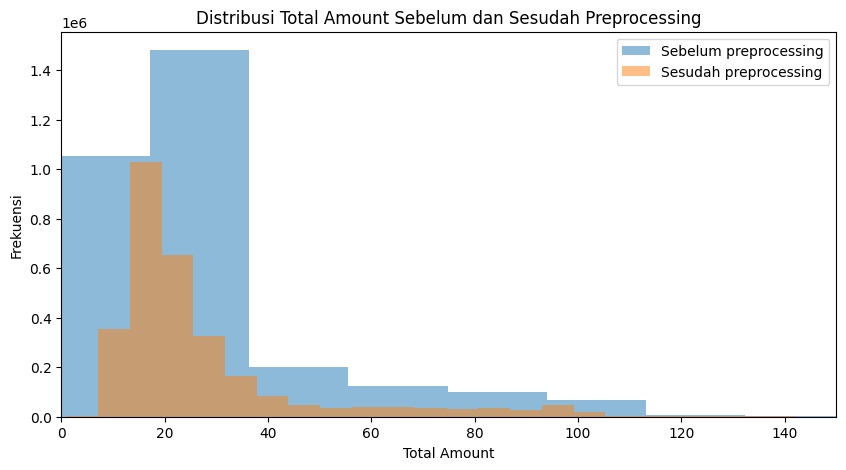

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    trip["total_amount"].dropna(),
    bins=100,
    alpha=0.5,
    label="Sebelum preprocessing"
)

plt.hist(
    bersih["total_amount"].dropna(),
    bins=100,
    alpha=0.5,
    label="Sesudah preprocessing"
)

plt.xlabel("Total Amount")
plt.ylabel("Frekuensi")
plt.title("Distribusi Total Amount Sebelum dan Sesudah Preprocessing")
plt.legend()
plt.xlim(0, 150)

plt.show()

Distribusi total_amount setelah preprocessing menjadi lebih terkendali karena data yang tidak valid berdasarkan aturan total_amount > 0, jarak perjalanan, dan durasi perjalanan telah disaring. Data hasil preprocessing tetap menunjukkan konsentrasi pada nilai transaksi yang relatif rendah, tetapi pengaruh nilai ekstrem menjadi lebih terbatas dibandingkan distribusi data sebelum preprocessing.

P. STUDI KASUS

1. Membuat tabel dynamic pricing

In [42]:
tabel_analitik = (
    bersih
    .assign(
        jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h")
    )
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_tarif_per_mil=("tarif_per_mil", "median"),
        rata_kecepatan=("kecepatan_mph", "median"),
        suhu_c=("suhu_c", "first"),
        hujan=("hujan", "max")
    )
    .reset_index()
)

# Kelompok kecil tidak digunakan untuk penarikan kesimpulan
tabel_analitik = tabel_analitik.loc[
    tabel_analitik["jumlah_perjalanan"] >= 30
].reset_index(drop=True)

PATH_TABEL_ANALITIK = f"{DIR_SIMPAN}/tabel_analitik_pricing.parquet"
PATH_KAMUS_DATA = f"{DIR_SIMPAN}/kamus_data.md"

tabel_analitik.to_parquet(
    PATH_TABEL_ANALITIK,
    index=False
)

isi_kamus = """# Kamus Data Tabel Analitik Pricing

| Kolom | Tipe/Satuan | Definisi dan cara penghitungan |
|---|---|---|
| borough_naik | kategori | Borough lokasi penjemputan dari join PULocationID dengan taxi zone lookup. |
| jam_mulai | datetime, jam lokal New York | Waktu penjemputan yang dibulatkan ke awal jam. |
| jumlah_perjalanan | perjalanan | Jumlah baris perjalanan pada borough dan jam yang sama. Hanya kelompok dengan minimal 30 perjalanan yang disimpan. |
| rata_tarif_per_mil | USD/mil | Median total_amount dibagi trip_distance pada kelompok. Nama kolom dipertahankan mengikuti kebutuhan tim, tetapi statistik yang dipakai adalah median. |
| rata_kecepatan | mil/jam | Median trip_distance dibagi durasi perjalanan dalam jam. |
| suhu_c | derajat Celsius | Nilai suhu pertama pada jam yang sama dari Open-Meteo. |
| hujan | 0 atau 1 | Bernilai 1 apabila hujan_mm pada jam tersebut lebih dari 0,1 mm; selain itu 0. |

## Sumber

NYC TLC Yellow Taxi Trip Records Januari 2023, NYC Taxi Zone Lookup, referensi payment_type, dan Open-Meteo Archive API.
"""

with open(PATH_KAMUS_DATA, "w", encoding="utf-8") as berkas:
    berkas.write(isi_kamus)

lineage[:] = [
    item for item in lineage
    if item["sumber"] != "tabel_analitik_pricing"
]
catat_sumber(
    "tabel_analitik_pricing",
    "hasil kurasi trip + zona + cuaca",
    len(tabel_analitik),
    "Satu baris per borough per jam; minimal 30 perjalanan"
)
pd.DataFrame(lineage).to_csv(
    f"{DIR_SIMPAN}/lineage.csv",
    index=False
)

print("Ukuran tabel analitik:", tabel_analitik.shape)
print("Parquet   :", PATH_TABEL_ANALITIK)
print("Kamus data:", PATH_KAMUS_DATA)
display(tabel_analitik.head())


[lineage] tabel_analitik_pricing: 2,094 baris
Ukuran tabel analitik: (2094, 7)
Parquet   : /content/drive/MyDrive/BigData/Praktikum3/tabel_analitik_pricing.parquet
Kamus data: /content/drive/MyDrive/BigData/Praktikum3/kamus_data.md


,borough_naik,jam_mulai,jumlah_perjalanan,rata_tarif_per_mil,rata_kecepatan,suhu_c,hujan
0,Brooklyn,2023-01-01 00:00:00,86,6.9385,14.550,10.9,1
1,Brooklyn,2023-01-01 01:00:00,220,6.9820,13.715,10.6,1
2,Brooklyn,2023-01-01 02:00:00,256,6.6215,15.445,10.6,0
3,Brooklyn,2023-01-01 03:00:00,175,6.6160,16.390,10.5,0
4,Brooklyn,2023-01-01 04:00:00,74,6.9120,14.635,9.8,0


2.Membandingkan Tarif pada Jam Hujan dan Tidak Hujan

In [43]:
perbandingan_hujan = (
    tabel_analitik
    .groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
    .median()
    .unstack()
    .reindex(columns=[0, 1])
    .rename(columns={
        0: "median_tidak_hujan",
        1: "median_hujan"
    })
)

perbandingan_hujan["selisih"] = (
    perbandingan_hujan["median_hujan"]
    - perbandingan_hujan["median_tidak_hujan"]
)
perbandingan_hujan["perubahan_persen"] = (
    100
    * perbandingan_hujan["selisih"]
    / perbandingan_hujan["median_tidak_hujan"]
).round(2)

perbandingan_hujan = perbandingan_hujan.round(3)
display(perbandingan_hujan)

perbandingan_hujan.to_csv(
    f"{DIR_SIMPAN}/perbandingan_tarif_hujan_per_borough.csv"
)


hujan,median_tidak_hujan,median_hujan,selisih,perubahan_persen
borough_naik,,,,
Brooklyn,6.943,7.655,0.712,10.25
Manhattan,10.527,11.400,0.873,8.29
Queens,5.453,5.636,0.183,3.37
Unknown,8.726,9.886,1.160,13.30


### 3. Batasan Analisis

Terdapat beberapa batasan yang perlu diperhatikan dalam menggunakan hasil analisis dynamic pricing ini. Pertama, kolom `rata_tarif_per_mil` menggunakan median, bukan rata-rata aritmetika, karena distribusi tarif per mil pada data perjalanan dapat memiliki kemencengan ke kanan dan nilai ekstrem. Penggunaan median membantu mengurangi pengaruh perjalanan dengan tarif yang sangat tinggi, tetapi menyebabkan hasil tidak dapat diartikan sebagai rata-rata tarif per mil sebenarnya. Kedua, data cuaca diperoleh dari satu titik pengamatan di New York dan digunakan untuk merepresentasikan kondisi cuaca pada seluruh wilayah perjalanan, sehingga kondisi hujan pada suatu jam belum tentu menggambarkan kondisi cuaca yang sama di setiap borough. Ketiga, perbedaan tarif antara kondisi hujan dan tidak hujan tidak dapat digunakan untuk menyimpulkan hubungan sebab-akibat. Hujan dapat terjadi bersamaan dengan faktor lain seperti jam sibuk, perubahan jumlah permintaan perjalanan, kepadatan lalu lintas, dan karakteristik perjalanan. Keempat, tabel analitik hanya menggunakan kelompok dengan minimal 30 perjalanan sehingga kelompok dengan jumlah perjalanan yang lebih sedikit tidak digunakan dalam analisis untuk mengurangi risiko kesimpulan dari sampel yang terlalu kecil.

### 4. Pembaruan Otomatis Setiap Bulan

Agar tabel analitik dapat diperbarui secara otomatis setiap bulan, pipeline perlu dibuat dalam bentuk fungsi yang menerima parameter bulan sebagai input. Proses dimulai dengan memeriksa apakah data bulan tersebut sudah tersedia pada penyimpanan mentah atau cache. Jika belum tersedia, pipeline mengunduh data perjalanan bulan tersebut menggunakan mekanisme retry dan penulisan atomik, kemudian mengambil data cuaca untuk periode yang sama. Setelah itu data diproses menggunakan tahapan preprocessing yang sama seperti pada K-6 sampai K-10, yaitu validasi kualitas data, penanganan missing value dan duplikat, penyaringan data tidak valid, join dengan tabel zona dan pembayaran, serta penggabungan data cuaca berdasarkan `jam_mulai`. Selanjutnya tabel dynamic pricing dibuat dengan tingkat rincian satu baris per borough per jam dan disimpan dalam format Parquet pada direktori keluaran yang sama dengan partisi berdasarkan bulan. Pipeline juga harus bersifat idempoten sehingga ketika bulan yang sama dijalankan kembali, hasil tidak diduplikasi. Dengan cara tersebut, ketika memasuki bulan baru, cukup menjalankan pipeline dengan parameter bulan tersebut dan sistem akan menambahkan hasil bulan baru tanpa mengubah data bulan sebelumnya.

**Q. LATIHAN**

Q1. Kecepatan Download dan Cache

In [44]:
# ============================================================
# Q1 - DOWNLOAD SPEED + CACHE
# ============================================================

import os
import time
import requests
import shutil

def unduh_aman_speed(url, tujuan, percobaan=3, jeda_awal=2):
    """Download dengan retry, atomic write, cache, dan kecepatan MB/s."""

    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"

    for i in range(percobaan):
        try:
            t0 = time.perf_counter()

            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()

                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)

            ukuran_byte = os.path.getsize(sementara)

            if ukuran_byte == 0:
                raise IOError("berkas kosong")

            os.replace(sementara, tujuan)

            detik = time.perf_counter() - t0
            ukuran_mb = ukuran_byte / 1024**2
            kecepatan = ukuran_mb / detik

            print(f"berhasil: {os.path.basename(tujuan)}")
            print(f"ukuran    : {ukuran_mb:.2f} MB")
            print(f"waktu     : {detik:.2f} detik")
            print(f"kecepatan : {kecepatan:.2f} MB/detik")

            return tujuan

        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(
                f"percobaan {i+1} gagal ({e}); "
                f"menunggu {jeda}s"
            )
            time.sleep(jeda)

    raise RuntimeError(
        f"gagal mengunduh setelah {percobaan} percobaan: {url}"
    )

In [45]:
Q1_PATH = os.path.join(
    DIR_MENTAH,
    "yellow_tripdata_2023-01-q1.parquet"
)

Q1_URL = (
    "https://d37ci6vzurychx.cloudfront.net/"
    "trip-data/yellow_tripdata_2023-01.parquet"
)

unduh_aman_speed(Q1_URL, Q1_PATH)

berhasil: yellow_tripdata_2023-01-q1.parquet
ukuran    : 45.46 MB
waktu     : 0.35 detik
kecepatan : 130.87 MB/detik


'/content/lapisan_mentah/yellow_tripdata_2023-01-q1.parquet'

Pada eksekusi pertama, file belum tersedia sehingga fungsi melakukan proses pengunduhan dan menampilkan ukuran file, waktu pengunduhan, serta kecepatan dalam MB/detik. Pada eksekusi kedua, file sudah tersedia sehingga fungsi mendeteksi cache dan tidak melakukan pengunduhan ulang. Hal ini menunjukkan bahwa mekanisme caching membuat pipeline lebih efisien ketika notebook dijalankan kembali.

Q2. Dua Aturan Baru Kualitas Data

In [46]:
# ============================================================
# Q2 - TAMBAHAN ATURAN KUALITAS DATA
# ============================================================

# Aturan 1: tip_amount tidak boleh negatif
aturan_tip = bersih["tip_amount"].ge(0)

# Aturan 2: total_amount minimal mencakup fare + tip
aturan_konsistensi = (
    bersih["total_amount"]
    >= bersih["fare_amount"] + bersih["tip_amount"]
)

q2_laporan = pd.DataFrame([
    {
        "aturan": "tip_amount >= 0",
        "lulus": int(aturan_tip.sum()),
        "gagal": int((~aturan_tip).sum()),
        "persen_gagal": round((~aturan_tip).mean() * 100, 3)
    },
    {
        "aturan": "total_amount >= fare_amount + tip_amount",
        "lulus": int(aturan_konsistensi.sum()),
        "gagal": int((~aturan_konsistensi).sum()),
        "persen_gagal": round(
            (~aturan_konsistensi).mean() * 100,
            3
        )
    }
])

q2_laporan

,aturan,lulus,gagal,persen_gagal
0,tip_amount >= 0,2986908,2,0.0
1,total_amount >= fare_amount + tip_amount,2986908,2,0.0


### Analisis Q2

Dua aturan tambahan digunakan untuk memperluas pemeriksaan kualitas data. Aturan pertama memeriksa validitas `tip_amount`, yaitu nilai tip tidak boleh negatif. Aturan kedua memeriksa konsistensi antar kolom dengan memastikan `total_amount` tidak lebih kecil daripada gabungan `fare_amount` dan `tip_amount`. Persentase kegagalan masing-masing aturan diperoleh dengan membandingkan jumlah baris yang tidak memenuhi aturan terhadap seluruh baris pada dataset `bersih`. Nilai persentase kegagalan menunjukkan seberapa banyak data yang berpotensi melanggar aturan bisnis tersebut.

Q3. Join Lokasi Tujuan + 10 Pasangan Borough Terbanyak

In [47]:
# ============================================================
# Q3 - JOIN DESTINATION LOCATION
# ============================================================

zona_tujuan = zona[
    ["LocationID", "Borough"]
].rename(
    columns={
        "LocationID": "DOLocationID",
        "Borough": "borough_turun"
    }
)

# Pastikan LocationID pada tabel zona unik
print(
    "LocationID unik:",
    zona["LocationID"].is_unique
)

# Join lokasi tujuan
bersih_q3 = bersih.merge(
    zona_tujuan,
    on="DOLocationID",
    how="left",
    validate="many_to_one"
)

print(
    f"Baris sebelum join : {len(bersih):,}"
)
print(
    f"Baris sesudah join : {len(bersih_q3):,}"
)
print(
    "Borough tujuan tidak ditemukan:",
    bersih_q3["borough_turun"].isna().sum()
)

LocationID unik: True
Baris sebelum join : 2,986,910
Baris sesudah join : 2,986,910
Borough tujuan tidak ditemukan: 9511


In [48]:
top10_od = (
    bersih_q3
    .groupby(
        ["borough_naik", "borough_turun"],
        dropna=False
    )
    .size()
    .reset_index(name="jumlah_perjalanan")
    .sort_values(
        "jumlah_perjalanan",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

top10_od

,borough_naik,borough_turun,jumlah_perjalanan
0,Manhattan,Manhattan,2491566
1,Queens,Manhattan,155261
2,Manhattan,Queens,82354
3,Manhattan,Brooklyn,62986
4,Queens,Queens,59146
5,Queens,Brooklyn,42187
6,Unknown,Manhattan,18432
7,Unknown,Unknown,13562
8,Manhattan,Bronx,8865
9,Brooklyn,Brooklyn,7910


Q4. StandardScaler vs MinMaxScaler

In [50]:
# ============================================================
# Q4 - STANDARD SCALER VS MINMAX SCALER
# ============================================================

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# -------------------------------
# StandardScaler
# -------------------------------

scaler_standard = StandardScaler()

latih_standard = scaler_standard.fit_transform(
    latih[FITUR_NUM]
)

uji_standard = scaler_standard.transform(
    uji[FITUR_NUM]
)

# -------------------------------
# MinMaxScaler
# -------------------------------

scaler_minmax = MinMaxScaler()

latih_minmax = scaler_minmax.fit_transform(
    latih[FITUR_NUM]
)

uji_minmax = scaler_minmax.transform(
    uji[FITUR_NUM]
)

print("StandardScaler")
print(
    "min:",
    latih_standard.min(axis=0)
)
print(
    "max:",
    latih_standard.max(axis=0)
)

print("\nMinMaxScaler")
print(
    "min:",
    latih_minmax.min(axis=0)
)
print(
    "max:",
    latih_minmax.max(axis=0)
)

hasil_scaling = []

for i, fitur in enumerate(FITUR_NUM):

    hasil_scaling.append({
        "fitur": fitur,

        "standard_min":
            latih_standard[:, i].min(),

        "standard_max":
            latih_standard[:, i].max(),

        "minmax_min":
            latih_minmax[:, i].min(),

        "minmax_max":
            latih_minmax[:, i].max()
    })

perbandingan_scaling = pd.DataFrame(
    hasil_scaling
)

perbandingan_scaling

StandardScaler
min: [-0.79394819 -1.22597486 -2.28810005]
max: [ 4.24679249 13.92481023  3.34748746]

MinMaxScaler
min: [0. 0. 0.]
max: [1. 1. 1.]


,fitur,standard_min,standard_max,minmax_min,minmax_max
0,trip_distance_capped,-0.793948,4.246792,0.0,1.0
1,durasi_menit,-1.225975,13.924810,0.0,1.0
2,suhu_c,-2.288100,3.347487,0.0,1.0


StandardScaler memusatkan data terhadap rata-rata dan mengubah skala berdasarkan simpangan baku, sedangkan MinMaxScaler memetakan rentang data latih ke 0-1. Perbedaan skala penting bagi algoritma berbasis jarak atau gradien, seperti KNN, SVM, regresi dengan regularisasi, dan jaringan saraf. Model berbasis pohon keputusan umumnya tidak sensitif terhadap perubahan skala monoton karena pemisahannya menggunakan urutan nilai dan ambang.

Q5. Membuktikan validate="many_to_one"

In [51]:
# ============================================================
# Q5 - MEMBUAT DUPLIKAT PADA TABEL ZONA
# ============================================================

zona_test = zona.copy()

# Gandakan satu baris
zona_test = pd.concat(
    [
        zona_test,
        zona_test.iloc[[0]]
    ],
    ignore_index=True
)

print(
    "Jumlah baris zona asli :",
    len(zona)
)

print(
    "Jumlah baris zona test :",
    len(zona_test)
)

print(
    "LocationID unik setelah duplikasi:",
    zona_test["LocationID"].is_unique
)

Jumlah baris zona asli : 265
Jumlah baris zona test : 266
LocationID unik setelah duplikasi: False


In [52]:
try:

    hasil_test = bersih.merge(
        zona_test[
            ["LocationID", "Borough"]
        ].rename(
            columns={
                "Borough": "borough_naik"
            }
        ),

        left_on="PULocationID",
        right_on="LocationID",

        how="left",

        validate="many_to_one"
    )

except Exception as e:

    print("ERROR TERDETEKSI:")
    print(type(e).__name__)
    print(e)

ERROR TERDETEKSI:
MergeError
Merge keys are not unique in right dataset; not a many-to-one merge


In [53]:
print(
    "Zona asli tetap:",
    zona["LocationID"].is_unique
)

print(
    "Jumlah baris zona asli:",
    len(zona)
)

Zona asli tetap: True
Jumlah baris zona asli: 265


### Analisis Q5

Pengujian dilakukan dengan menggandakan satu baris pada tabel zona sehingga terdapat dua baris dengan `LocationID` yang sama. Ketika tabel tersebut digunakan dalam `merge()` dengan `validate="many_to_one"`, pandas menghasilkan `MergeError` karena kunci pada sisi kanan tidak lagi unik. Hal ini membuktikan bahwa `validate="many_to_one"` dapat mencegah join yang berpotensi menggandakan jumlah baris transaksi. Setelah pengujian selesai, tabel asli tidak berubah karena duplikasi hanya dilakukan pada salinan `zona_test`.

Q6. pipeline_inkremental(bulan)

In [54]:
# ============================================================
# Q6 - PIPELINE INKREMENTAL
# ============================================================

from pathlib import Path

BASE_URL_TRIP = (
    "https://d37ci6vzurychx.cloudfront.net/"
    "trip-data/yellow_tripdata_{bulan}.parquet"
)

DIR_OUTPUT_INK = os.path.join(
    DIR_KURASI,
    "trips_bersih_incremental"
)

os.makedirs(
    DIR_OUTPUT_INK,
    exist_ok=True
)

In [55]:
def pipeline_inkremental(bulan):
    """
    Memproses satu bulan hanya jika hasil bulan tersebut
    belum tersedia.

    Format bulan:
    YYYY-MM
    """

    nama_file = f"yellow_tripdata_{bulan}.parquet"

    path_trip_bulan = os.path.join(
        DIR_MENTAH,
        nama_file
    )

    url_trip_bulan = BASE_URL_TRIP.format(
        bulan=bulan
    )

    # -----------------------------------------
    # 1. Cek apakah output sudah ada
    # -----------------------------------------

    folder_output = os.path.join(
        DIR_OUTPUT_INK,
        f"bulan={bulan}"
    )

    if os.path.exists(folder_output):

        print(
            f"[SKIP] Hasil bulan {bulan} "
            "sudah tersedia."
        )

        return {
            "bulan": bulan,
            "status": "SKIP",
            "file_baru": False
        }

    # -----------------------------------------
    # 2. Download data jika belum ada
    # -----------------------------------------

    print(
        f"[PROSES] Mengambil data bulan {bulan}"
    )

    unduh_aman_speed(
        url_trip_bulan,
        path_trip_bulan
    )

    # -----------------------------------------
    # 3. Jalankan pipeline
    # -----------------------------------------

    hasil_bulan = pipeline(
        path_trip_bulan,
        PATH_ZONA,
        cuaca,
        tarif_referensi
    )

    # -----------------------------------------
    # 4. Simpan hasil
    # -----------------------------------------

    hasil_bulan["bulan"] = bulan

    hasil_bulan.to_parquet(
        folder_output,
        index=False
    )

    print(
        f"[SELESAI] {bulan}: "
        f"{len(hasil_bulan):,} baris"
    )

    return {
        "bulan": bulan,
        "status": "PROSES",
        "file_baru": True,
        "jumlah_baris": len(hasil_bulan)
    }

In [56]:
hasil_q6_1 = pipeline_inkremental(
    "2023-01"
)

hasil_q6_1

[PROSES] Mengambil data bulan 2023-01
cache ditemukan: yellow_tripdata_2023-01.parquet
Validasi lulus: 2,986,910 baris x 17 kolom
[SELESAI] 2023-01: 2,986,910 baris


{'bulan': '2023-01',
 'status': 'PROSES',
 'file_baru': True,
 'jumlah_baris': 2986910}

In [57]:
hasil_q6_2 = pipeline_inkremental(
    "2023-01"
)

hasil_q6_2

[SKIP] Hasil bulan 2023-01 sudah tersedia.


{'bulan': '2023-01', 'status': 'SKIP', 'file_baru': False}

In [58]:
print(
    "Pemanggilan pertama :",
    hasil_q6_1
)

print(
    "Pemanggilan kedua   :",
    hasil_q6_2
)

print(
    "Idempoten?",
    hasil_q6_2["file_baru"] == False
)

Pemanggilan pertama : {'bulan': '2023-01', 'status': 'PROSES', 'file_baru': True, 'jumlah_baris': 2986910}
Pemanggilan kedua   : {'bulan': '2023-01', 'status': 'SKIP', 'file_baru': False}
Idempoten? True


R.TUGAS PRAKTIKUM

In [66]:
import importlib.util
import subprocess
import sys

pustaka = {
    "pandas": "pandas",
    "numpy": "numpy",
    "pyarrow": "pyarrow",
    "requests": "requests",
    "matplotlib": "matplotlib",
    "psutil": "psutil",
}

belum_terpasang = [
    paket for modul, paket in pustaka.items()
    if importlib.util.find_spec(modul) is None
]

if belum_terpasang:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        *belum_terpasang
    ])

import gc
import hashlib
import json
import os
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import pyarrow
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import requests
from IPython.display import Image, display

try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_CONTENT = Path("/content")
    BASE_DRIVE = Path("/content/drive/MyDrive")
except ImportError:
    # Jalur ini hanya dipakai ketika notebook diuji di luar Colab.
    BASE_CONTENT = Path.cwd() / "content"
    BASE_DRIVE = Path.cwd() / "drive"

PERIODE = ["2023-01", "2023-07"]

DIR_MENTAH = BASE_CONTENT / "lapisan_mentah_tugas_p03"
DIR_KURASI = BASE_CONTENT / "lapisan_terkurasi_tugas_p03"
DIR_SIMPAN = BASE_DRIVE / "BigData" / "Praktikum3" / "TugasPraktikum3"
DIR_OUTPUT = DIR_SIMPAN / "trips_bersih"
DIR_ARTEFAK = DIR_SIMPAN / "artefak"

for direktori in (
    DIR_MENTAH, DIR_KURASI, DIR_SIMPAN,
    DIR_OUTPUT, DIR_ARTEFAK
):
    direktori.mkdir(parents=True, exist_ok=True)

print("Python   :", sys.version.split()[0])
print("pandas   :", pd.__version__)
print("NumPy    :", np.__version__)
print("PyArrow  :", pyarrow.__version__)
print("requests :", requests.__version__)
print("Periode  :", PERIODE)
print("Output   :", DIR_SIMPAN)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Python   : 3.13.15
pandas   : 2.2.3
NumPy    : 2.1.3
PyArrow  : 23.0.1
requests : 2.32.4
Periode  : ['2023-01', '2023-07']
Output   : /content/drive/MyDrive/BigData/Praktikum3/TugasPraktikum3


1 Fungsi Umum, Cache, dan Pencatatan

In [67]:
proses = psutil.Process(os.getpid())
catatan_kinerja = []
lineage_records = []


def rss_mb():
    return proses.memory_info().rss / 1024**2


def ukur(label, fungsi):
    memori_awal = rss_mb()
    waktu_awal = time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - waktu_awal
    delta_memori = rss_mb() - memori_awal

    catatan_kinerja.append({
        "langkah": label,
        "detik": round(detik, 2),
        "delta_rss_mb": round(delta_memori, 1),
    })
    print(
        f"[{label}] {detik:.2f} detik | "
        f"delta RSS: {delta_memori:.1f} MB"
    )
    return hasil


def catat_lineage(sumber, periode, asal, jumlah_baris, keterangan):
    lineage_records.append({
        "sumber": sumber,
        "periode": periode,
        "asal": asal,
        "diambil_pada_utc": pd.Timestamp.now(tz="UTC").isoformat(),
        "jumlah_baris": int(jumlah_baris),
        "keterangan": keterangan,
    })


def sha256_file(path, ukuran_blok=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as berkas:
        while blok := berkas.read(ukuran_blok):
            digest.update(blok)
    return digest.hexdigest()


def cache_valid(path, jenis):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return False

    try:
        if jenis == "parquet":
            pq.ParquetFile(path)
        elif jenis == "csv":
            pd.read_csv(path, nrows=3)
        elif jenis == "json":
            with open(path, encoding="utf-8") as berkas:
                json.load(berkas)
        else:
            raise ValueError(f"Jenis berkas tidak didukung: {jenis}")
        return True
    except Exception:
        return False


def unduh_aman(url, tujuan, jenis, percobaan=3, jeda_awal=2):
    tujuan = Path(tujuan)
    tujuan.parent.mkdir(parents=True, exist_ok=True)

    if cache_valid(tujuan, jenis):
        print(f"Cache ditemukan: {tujuan.name}")
        return tujuan

    sementara = tujuan.with_suffix(tujuan.suffix + ".part")
    if sementara.exists():
        sementara.unlink()

    for indeks in range(percobaan):
        try:
            waktu_awal = time.perf_counter()
            jumlah_byte = 0

            with requests.get(url, stream=True, timeout=120) as respons:
                if respons.status_code in (429, 500, 502, 503, 504):
                    raise requests.HTTPError(
                        f"Status sementara {respons.status_code}"
                    )
                respons.raise_for_status()

                with open(sementara, "wb") as berkas:
                    for blok in respons.iter_content(chunk_size=1024 * 1024):
                        if blok:
                            berkas.write(blok)
                            jumlah_byte += len(blok)

            if not cache_valid(sementara, jenis):
                raise ValueError("Berkas hasil unduhan tidak valid")

            os.replace(sementara, tujuan)
            detik = max(time.perf_counter() - waktu_awal, 1e-9)
            kecepatan = jumlah_byte / 1024**2 / detik
            print(
                f"Unduhan selesai: {tujuan.name} | "
                f"{kecepatan:.2f} MB/detik"
            )
            return tujuan

        except Exception as error:
            if sementara.exists():
                sementara.unlink()
            if indeks == percobaan - 1:
                raise
            tunggu = jeda_awal * (2 ** indeks)
            print(f"Percobaan gagal: {error}. Ulang {tunggu} detik.")
            time.sleep(tunggu)

    raise RuntimeError("Unduhan tidak berhasil")

Hasil pemeriksaan menunjukkan bahwa data Januari 2023 dan Juli 2023 dapat disimpan pada direktori berpartisi yang sama.

2 Laporan Kualitas Komparatif

In [68]:
URL_ZONA = (
    "https://d37ci6vzurychx.cloudfront.net/"
    "misc/taxi_zone_lookup.csv"
)
PATH_ZONA = DIR_MENTAH / "taxi_zone_lookup.csv"

unduh_aman(URL_ZONA, PATH_ZONA, "csv")

# keep_default_na=False mempertahankan teks literal seperti "N/A".
zona = pd.read_csv(PATH_ZONA, keep_default_na=False)

if not zona["LocationID"].is_unique:
    raise ValueError("LocationID pada tabel zona tidak unik")

referensi_pembayaran = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": [
        "Kartu kredit", "Tunai", "Gratis",
        "Sengketa", "Tidak diketahui", "Perjalanan batal"
    ],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})

URL_LIBUR = (
    "https://date.nager.at/api/v3/"
    "PublicHolidays/2023/US"
)
PATH_LIBUR = DIR_MENTAH / "hari_libur_us_2023.json"

unduh_aman(URL_LIBUR, PATH_LIBUR, "json")

with open(PATH_LIBUR, encoding="utf-8") as berkas:
    libur_raw = json.load(berkas)

libur = pd.DataFrame(libur_raw)
kolom_wajib_libur = {"date", "name", "global"}
if not kolom_wajib_libur.issubset(libur.columns):
    raise ValueError("Struktur respons API hari libur berubah")

libur = (
    libur.loc[libur["global"].fillna(False), ["date", "name"]]
    .assign(tanggal=lambda d: pd.to_datetime(d["date"]))
    .groupby("tanggal", as_index=False)
    .agg(nama_libur=("name", lambda s: " / ".join(dict.fromkeys(s))))
)
libur["libur_nasional"] = np.int8(1)

catat_lineage(
    "taxi_zone_lookup", "referensi", URL_ZONA,
    len(zona), "Tabel referensi zona NYC TLC"
)
catat_lineage(
    "hari_libur_us", "2023", URL_LIBUR,
    len(libur), "Sumber keempat; hari libur nasional AS"
)

print("Tabel zona      :", zona.shape)
print("Hari libur 2023 :", libur.shape)
display(libur.head())

Unduhan selesai: taxi_zone_lookup.csv | 0.12 MB/detik
Unduhan selesai: hari_libur_us_2023.json | 0.04 MB/detik
Tabel zona      : (265, 4)
Hari libur 2023 : (11, 3)


,tanggal,nama_libur,libur_nasional
0,2023-01-02,New Year's Day,1
1,2023-01-16,"Martin Luther King, Jr. Day",1
2,2023-02-20,Presidents Day,1
3,2023-05-29,Memorial Day,1
4,2023-06-19,Juneteenth National Independence Day,1


Tabel zona dibaca dengan keep_default_na=False agar nama zona yang tertulis N/A tidak otomatis berubah menjadi nilai kosong. Data hari libur disaring ke hari libur berskala nasional, lalu diringkas menjadi satu baris per tanggal supaya aman digunakan dalam join many_to_one.

3 Fungsi Akuisisi Cuaca dan Laporan Kualitas

In [69]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"


def simpan_json_atomik(data, tujuan):
    tujuan = Path(tujuan)
    sementara = tujuan.with_suffix(tujuan.suffix + ".part")
    with open(sementara, "w", encoding="utf-8") as berkas:
        json.dump(data, berkas, ensure_ascii=False)
    os.replace(sementara, tujuan)


def ambil_cuaca(bulan, percobaan=3):
    periode = pd.Period(bulan, freq="M")
    tanggal_awal = periode.start_time.strftime("%Y-%m-%d")
    tanggal_akhir = periode.end_time.strftime("%Y-%m-%d")
    path_cache = DIR_MENTAH / f"cuaca_{bulan}.json"

    if cache_valid(path_cache, "json"):
        with open(path_cache, encoding="utf-8") as berkas:
            data = json.load(berkas)
        print(f"Cache cuaca ditemukan: {path_cache.name}")
    else:
        params = {
            "latitude": 40.7128,
            "longitude": -74.0060,
            "start_date": tanggal_awal,
            "end_date": tanggal_akhir,
            "hourly": "temperature_2m,precipitation",
            "timezone": "America/New_York",
        }

        for indeks in range(percobaan):
            try:
                respons = requests.get(
                    API_CUACA, params=params, timeout=120
                )
                if respons.status_code in (429, 500, 502, 503, 504):
                    raise requests.HTTPError(
                        f"Status sementara {respons.status_code}"
                    )
                respons.raise_for_status()
                data = respons.json()
                if "hourly" not in data:
                    raise ValueError("Bagian hourly tidak ditemukan")
                simpan_json_atomik(data, path_cache)
                break
            except Exception:
                if indeks == percobaan - 1:
                    raise
                time.sleep(2 ** (indeks + 1))

    hourly = data.get("hourly", {})
    kolom_wajib = {"time", "temperature_2m", "precipitation"}
    if not kolom_wajib.issubset(hourly):
        raise ValueError("Kolom cuaca wajib tidak lengkap")

    cuaca = pd.DataFrame({
        "jam_mulai": pd.to_datetime(hourly["time"]),
        "suhu_c": pd.to_numeric(
            hourly["temperature_2m"], errors="coerce"
        ),
        "hujan_mm": pd.to_numeric(
            hourly["precipitation"], errors="coerce"
        ),
    })

    if not cuaca["jam_mulai"].is_unique:
        raise ValueError("Kunci jam pada data cuaca tidak unik")

    catat_lineage(
        "open_meteo", bulan, API_CUACA, len(cuaca),
        "Suhu dan presipitasi per jam di New York City"
    )
    return cuaca


def buat_laporan_kualitas(trip, bulan, zona_ref):
    periode = pd.Period(bulan, freq="M")
    awal = periode.start_time
    akhir = (periode + 1).start_time

    aturan = {
        "kelengkapan: passenger_count ada": (
            trip["passenger_count"].notna()
        ),
        "validitas: jarak 0,01-100 mil": (
            trip["trip_distance"].between(0.01, 100)
        ),
        "konsistensi: durasi 1-180 menit": (
            trip["durasi_menit"].between(1, 180)
        ),
        "validitas: total_amount > 0": (
            trip["total_amount"] > 0
        ),
        "konsistensi: total >= fare": (
            trip["total_amount"] >= trip["fare_amount"]
        ),
        "ketepatan waktu: dalam periode berkas": (
            trip["tpep_pickup_datetime"].ge(awal)
            & trip["tpep_pickup_datetime"].lt(akhir)
        ),
        "keunikan: baris tidak duplikat": (
            ~trip.duplicated()
        ),
        "validitas: PULocationID dikenal": (
            trip["PULocationID"].isin(zona_ref["LocationID"])
        ),
    }

    hasil = []
    for nama, mask in aturan.items():
        mask = mask.fillna(False)
        lulus = int(mask.sum())
        gagal = int((~mask).sum())
        hasil.append({
            "periode": bulan,
            "aturan": nama,
            "lulus": lulus,
            "gagal": gagal,
            "persen_gagal": round(gagal / len(trip) * 100, 4),
        })

    return pd.DataFrame(hasil).sort_values(
        "persen_gagal", ascending=False
    ).reset_index(drop=True)

4 Pipeline Dua Bulan

In [70]:
KOLOM_TRIP = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount",
]

KUNCI_PERJALANAN = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "total_amount",
]

KOLOM_AKHIR = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "passenger_count_diimputasi",
    "trip_distance",
    "trip_distance_capped",
    "durasi_menit",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "tarif_ekstrem",
    "zona_naik",
    "borough_naik",
    "service_zone",
    "nama_pembayaran",
    "kena_biaya_admin",
    "jam_mulai",
    "suhu_c",
    "hujan_mm",
    "cuaca_tersedia",
    "hujan",
    "tanggal",
    "nama_libur",
    "libur_nasional",
    "hari_minggu",
    "akhir_pekan",
    "kecepatan_mph",
    "tarif_per_mil",
    "periode",
]


def validasi_hasil(data, bulan):
    hilang = sorted(set(KOLOM_AKHIR) - set(data.columns))
    if hilang:
        raise AssertionError(f"Kolom akhir belum lengkap: {hilang}")
    if data.empty:
        raise AssertionError("Dataset akhir kosong")
    if data.duplicated(KUNCI_PERJALANAN).any():
        raise AssertionError("Masih ada duplikat kunci perjalanan")
    if not data["periode"].eq(bulan).all():
        raise AssertionError("Label periode tidak konsisten")

    awal = pd.Period(bulan, freq="M").start_time
    akhir = (pd.Period(bulan, freq="M") + 1).start_time
    if not data["tpep_pickup_datetime"].between(
        awal, akhir, inclusive="left"
    ).all():
        raise AssertionError("Ada waktu pickup di luar periode")


def pipeline_bulan(bulan):
    dir_final = DIR_OUTPUT / f"periode={bulan}"
    path_sukses = dir_final / "_SUCCESS.json"

    # Idempotensi: keluaran lengkap tidak ditulis ulang.
    if path_sukses.exists():
        with open(path_sukses, encoding="utf-8") as berkas:
            metadata = json.load(berkas)
        metadata["status"] = "cache"
        for item in metadata.get("lineage", []):
            lineage_records.append(item)
        print(f"[{bulan}] cache keluaran ditemukan; proses dilewati")
        return metadata

    url_trip = (
        "https://d37ci6vzurychx.cloudfront.net/trip-data/"
        f"yellow_tripdata_{bulan}.parquet"
    )
    path_trip = DIR_MENTAH / f"yellow_tripdata_{bulan}.parquet"
    unduh_aman(url_trip, path_trip, "parquet")

    waktu_pipeline = time.perf_counter()
    rss_awal_pipeline = rss_mb()

    trip = ukur(
        f"{bulan}: baca parquet",
        lambda: pd.read_parquet(path_trip, columns=KOLOM_TRIP)
    )
    jumlah_awal = len(trip)

    trip["durasi_menit"] = (
        (
            trip["tpep_dropoff_datetime"]
            - trip["tpep_pickup_datetime"]
        ).dt.total_seconds() / 60
    )

    laporan = buat_laporan_kualitas(trip, bulan, zona)
    path_laporan = DIR_ARTEFAK / f"laporan_kualitas_{bulan}.csv"
    laporan.to_csv(path_laporan, index=False)

    periode = pd.Period(bulan, freq="M")
    awal = periode.start_time
    akhir = (periode + 1).start_time
    trip = trip.loc[
        trip["tpep_pickup_datetime"].ge(awal)
        & trip["tpep_pickup_datetime"].lt(akhir)
    ].copy()
    jumlah_dalam_periode = len(trip)

    trip["passenger_count_diimputasi"] = (
        trip["passenger_count"].isna().astype("int8")
    )
    jam_pickup = trip["tpep_pickup_datetime"].dt.hour
    median_per_jam = trip.groupby(
        jam_pickup, observed=True
    )["passenger_count"].transform("median")
    median_global = trip["passenger_count"].median()
    trip["passenger_count"] = (
        trip["passenger_count"]
        .fillna(median_per_jam)
        .fillna(median_global)
    )

    sebelum_duplikat = len(trip)
    trip = trip.drop_duplicates(
        subset=KUNCI_PERJALANAN, keep="first"
    ).copy()
    dibuang_duplikat = sebelum_duplikat - len(trip)

    mask_valid = (
        trip["trip_distance"].between(0.01, 100)
        & trip["durasi_menit"].between(1, 180)
        & trip["total_amount"].gt(0)
    )
    sebelum_filter = len(trip)
    trip = trip.loc[mask_valid].copy()
    dibuang_filter = sebelum_filter - len(trip)

    q1 = trip["total_amount"].quantile(0.25)
    q3 = trip["total_amount"].quantile(0.75)
    batas_tarif = q3 + 1.5 * (q3 - q1)
    trip["tarif_ekstrem"] = (
        trip["total_amount"] > batas_tarif
    ).astype("int8")

    batas_jarak = trip["trip_distance"].quantile(0.995)
    trip["trip_distance_capped"] = trip["trip_distance"].clip(
        upper=batas_jarak
    )

    zona_join = zona[[
        "LocationID", "Borough", "Zone", "service_zone"
    ]].rename(columns={
        "Borough": "borough_naik",
        "Zone": "zona_naik",
    })

    trip = trip.merge(
        zona_join,
        left_on="PULocationID",
        right_on="LocationID",
        how="left",
        validate="many_to_one",
    ).drop(columns="LocationID")

    trip["borough_naik"] = (
        trip["borough_naik"].replace("", np.nan)
        .fillna("Unknown")
    )
    trip["zona_naik"] = (
        trip["zona_naik"].replace("", np.nan)
        .fillna("Tidak diketahui")
    )
    trip["service_zone"] = (
        trip["service_zone"].replace("", np.nan)
        .fillna("Tidak diketahui")
    )

    trip = trip.merge(
        referensi_pembayaran,
        on="payment_type",
        how="left",
        validate="many_to_one",
    )
    trip["nama_pembayaran"] = trip[
        "nama_pembayaran"
    ].fillna("Tidak diketahui")
    trip["kena_biaya_admin"] = trip[
        "kena_biaya_admin"
    ].fillna(0).astype("int8")

    cuaca = ambil_cuaca(bulan)
    trip["jam_mulai"] = trip[
        "tpep_pickup_datetime"
    ].dt.floor("h")
    trip = trip.merge(
        cuaca,
        on="jam_mulai",
        how="left",
        validate="many_to_one",
    )

    trip["tanggal"] = trip[
        "tpep_pickup_datetime"
    ].dt.normalize()
    trip = trip.merge(
        libur,
        on="tanggal",
        how="left",
        validate="many_to_one",
    )
    trip["nama_libur"] = trip[
        "nama_libur"
    ].fillna("Bukan hari libur")
    trip["libur_nasional"] = trip[
        "libur_nasional"
    ].fillna(0).astype("int8")

    trip["cuaca_tersedia"] = (
        trip["suhu_c"].notna() & trip["hujan_mm"].notna()
    )
    trip["hujan"] = (
        trip["hujan_mm"].gt(0.1).astype("Int8")
    )
    trip.loc[~trip["cuaca_tersedia"], "hujan"] = pd.NA

    trip["hari_minggu"] = trip[
        "tpep_pickup_datetime"
    ].dt.dayofweek.astype("int8")
    trip["akhir_pekan"] = (
        trip["hari_minggu"] >= 5
    ).astype("int8")
    trip["kecepatan_mph"] = (
        trip["trip_distance"]
        / (trip["durasi_menit"] / 60)
    ).round(2)
    trip["tarif_per_mil"] = (
        trip["total_amount"] / trip["trip_distance"]
    ).round(3)
    trip["periode"] = bulan

    hasil = trip[KOLOM_AKHIR].copy()
    validasi_hasil(hasil, bulan)

    dir_sementara = DIR_OUTPUT / f".periode={bulan}.tmp"
    if dir_sementara.exists():
        shutil.rmtree(dir_sementara)
    if dir_final.exists():
        # Direktori tanpa _SUCCESS dianggap hasil tidak lengkap.
        shutil.rmtree(dir_final)

    hasil.to_parquet(
        dir_sementara,
        index=False,
        compression="snappy",
        partition_cols=["borough_naik"],
    )

    lineage_bulan = [
        {
            "sumber": "nyc_tlc_trip",
            "periode": bulan,
            "asal": url_trip,
            "diambil_pada_utc": pd.Timestamp.now(
                tz="UTC"
            ).isoformat(),
            "jumlah_baris": int(jumlah_awal),
            "keterangan": (
                "Data perjalanan mentah; sha256="
                + sha256_file(path_trip)
            ),
        },
        {
            "sumber": "dataset_bersih",
            "periode": bulan,
            "asal": str(path_trip),
            "diambil_pada_utc": pd.Timestamp.now(
                tz="UTC"
            ).isoformat(),
            "jumlah_baris": int(len(hasil)),
            "keterangan": (
                "Setelah filter periode, imputasi, deduplikasi, "
                "filter validitas, dan empat join"
            ),
        },
    ]
    lineage_records.extend(lineage_bulan)

    metadata = {
        "periode": bulan,
        "status": "dibuat",
        "baris_awal": int(jumlah_awal),
        "baris_dalam_periode": int(jumlah_dalam_periode),
        "baris_akhir": int(len(hasil)),
        "dibuang_luar_periode": int(
            jumlah_awal - jumlah_dalam_periode
        ),
        "dibuang_duplikat": int(dibuang_duplikat),
        "dibuang_filter": int(dibuang_filter),
        "cuaca_tidak_tersedia": int(
            (~hasil["cuaca_tersedia"]).sum()
        ),
        "baris_hari_libur": int(
            hasil["libur_nasional"].sum()
        ),
        "waktu_pipeline_detik": round(
            time.perf_counter() - waktu_pipeline, 2
        ),
        "delta_rss_mb": round(rss_mb() - rss_awal_pipeline, 1),
        "laporan_kualitas": str(path_laporan),
        "lineage": lineage_bulan,
    }

    with open(
        dir_sementara / "_SUCCESS.json",
        "w",
        encoding="utf-8",
    ) as berkas:
        json.dump(metadata, berkas, indent=2, ensure_ascii=False)

    os.replace(dir_sementara, dir_final)
    print(
        f"[{bulan}] {jumlah_awal:,} -> {len(hasil):,} baris | "
        f"tersimpan di {dir_final}"
    )

    del trip, hasil, cuaca, laporan
    gc.collect()
    return metadata

5 Menjalankan Pipeline Januari dan Juli 2023

In [71]:
metadata_bulan = {}

for bulan in PERIODE:
    metadata_bulan[bulan] = pipeline_bulan(bulan)
    gc.collect()

ringkasan_pipeline = pd.DataFrame([
    {
        "periode": bulan,
        "status": meta["status"],
        "baris_awal": meta["baris_awal"],
        "baris_akhir": meta["baris_akhir"],
        "persen_tersisa": round(
            meta["baris_akhir"] / meta["baris_awal"] * 100, 4
        ),
        "dibuang_luar_periode": meta["dibuang_luar_periode"],
        "dibuang_duplikat": meta["dibuang_duplikat"],
        "dibuang_filter": meta["dibuang_filter"],
        "waktu_pipeline_detik": meta["waktu_pipeline_detik"],
        "delta_rss_mb": meta["delta_rss_mb"],
    }
    for bulan, meta in metadata_bulan.items()
])

display(ringkasan_pipeline)

Unduhan selesai: yellow_tripdata_2023-01.parquet | 210.55 MB/detik
[2023-01: baca parquet] 1.77 detik | delta RSS: 246.4 MB
[2023-01] 3,066,766 -> 2,986,873 baris | tersimpan di /content/drive/MyDrive/BigData/Praktikum3/TugasPraktikum3/trips_bersih/periode=2023-01
Unduhan selesai: yellow_tripdata_2023-07.parquet | 19.77 MB/detik
[2023-07: baca parquet] 0.62 detik | delta RSS: 161.1 MB
[2023-07] 2,907,108 -> 2,817,607 baris | tersimpan di /content/drive/MyDrive/BigData/Praktikum3/TugasPraktikum3/trips_bersih/periode=2023-07


,periode,status,baris_awal,baris_akhir,persen_tersisa,dibuang_luar_periode,dibuang_duplikat,dibuang_filter,waktu_pipeline_detik,delta_rss_mb
0,2023-01,dibuat,3066766,2986873,97.3949,48,1,79844,53.76,2150.6
1,2023-07,dibuat,2907108,2817607,96.9213,59,0,89442,30.16,1286.9


6 Membuktikan Tidak Ada Duplikasi Antar-bulan

In [72]:
hash_periode = {}
ringkasan_duplikat = []

for bulan in PERIODE:
    path_bulan = DIR_OUTPUT / f"periode={bulan}"
    kunci = pd.read_parquet(
        path_bulan,
        columns=KUNCI_PERJALANAN,
    )
    duplikat_dalam = int(
        kunci.duplicated(KUNCI_PERJALANAN).sum()
    )
    hash_periode[bulan] = np.unique(
        pd.util.hash_pandas_object(
            kunci[KUNCI_PERJALANAN], index=False
        ).to_numpy()
    )
    ringkasan_duplikat.append({
        "periode": bulan,
        "jumlah_baris": len(kunci),
        "duplikat_dalam_bulan": duplikat_dalam,
    })
    del kunci
    gc.collect()

duplikat_antar_bulan = int(np.intersect1d(
    hash_periode[PERIODE[0]],
    hash_periode[PERIODE[1]],
    assume_unique=True,
).size)

tabel_duplikat = pd.DataFrame(ringkasan_duplikat)
display(tabel_duplikat)
print("Duplikat antar-bulan:", duplikat_antar_bulan)

assert tabel_duplikat["duplikat_dalam_bulan"].sum() == 0
assert duplikat_antar_bulan == 0
print("Validasi lulus: tidak ada duplikasi dalam atau antar-bulan.")

,periode,jumlah_baris,duplikat_dalam_bulan
0,2023-01,2986873,0
1,2023-07,2817607,0


Duplikat antar-bulan: 0
Validasi lulus: tidak ada duplikasi dalam atau antar-bulan.


7 Laporan Kualitas Komparatif

In [73]:
semua_laporan = []
for bulan in PERIODE:
    path = DIR_ARTEFAK / f"laporan_kualitas_{bulan}.csv"
    semua_laporan.append(pd.read_csv(path))

laporan_kualitas = pd.concat(
    semua_laporan, ignore_index=True
)
path_laporan_gabungan = DIR_SIMPAN / "laporan_kualitas.csv"
laporan_kualitas.to_csv(path_laporan_gabungan, index=False)

komparatif = laporan_kualitas.pivot(
    index="aturan",
    columns="periode",
    values="persen_gagal",
).reset_index()

kolom_awal, kolom_akhir = PERIODE
komparatif["selisih_poin_persen"] = (
    komparatif[kolom_akhir] - komparatif[kolom_awal]
).round(4)
komparatif["perubahan_absolut"] = (
    komparatif["selisih_poin_persen"].abs()
).round(4)
komparatif["perubahan_material"] = (
    komparatif["perubahan_absolut"] >= 0.5
)
komparatif = komparatif.sort_values(
    "perubahan_absolut", ascending=False
).reset_index(drop=True)

path_komparatif = DIR_ARTEFAK / "perbandingan_kualitas.csv"
komparatif.to_csv(path_komparatif, index=False)
display(komparatif)

dugaan = {
    "kelengkapan": (
        "Perbedaan dapat berkaitan dengan kelengkapan pelaporan "
        "passenger_count dari vendor atau skema pencatatan."
    ),
    "jarak": (
        "Perbedaan dapat berkaitan dengan pola perjalanan musiman "
        "atau nilai jarak yang tidak wajar."
    ),
    "durasi": (
        "Perbedaan dapat berkaitan dengan kemacetan, perjalanan "
        "sangat panjang, atau pencatatan waktu yang tidak konsisten."
    ),
    "total_amount": (
        "Perbedaan dapat berkaitan dengan koreksi transaksi, "
        "pengembalian dana, atau perjalanan tanpa pembayaran normal."
    ),
    "total >= fare": (
        "Perbedaan dapat berkaitan dengan komponen biaya dan transaksi "
        "koreksi yang tidak mengikuti pola pembayaran biasa."
    ),
    "ketepatan waktu": (
        "Perbedaan dapat berasal dari catatan pada batas bulan atau "
        "timestamp yang tidak sesuai nama berkas."
    ),
    "keunikan": (
        "Perbedaan dapat berasal dari pencatatan ulang transaksi."
    ),
    "PULocationID": (
        "Perbedaan dapat berasal dari kode lokasi khusus atau referensi "
        "zona yang belum mencakup kode tersebut."
    ),
}

print("\nTiga perubahan terbesar:")
for _, baris in komparatif.head(3).iterrows():
    alasan = next(
        (nilai for kunci, nilai in dugaan.items()
         if kunci in baris["aturan"]),
        "Perubahan perlu diperiksa kembali pada data mentah.",
    )
    arah = "naik" if baris["selisih_poin_persen"] > 0 else "turun"
    print(
        f"- {baris['aturan']}: {arah} "
        f"{abs(baris['selisih_poin_persen']):.4f} poin persentase. "
        f"{alasan}"
    )

periode,aturan,2023-01,2023-07,selisih_poin_persen,perubahan_absolut,perubahan_material
0,kelengkapan: passenger_count ada,2.3394,2.9268,0.5874,0.5874,True
1,konsistensi: total >= fare,0.8159,1.0535,0.2376,0.2376,False
2,validitas: total_amount > 0,0.8404,1.0746,0.2342,0.2342,False
3,"validitas: jarak 0,01-100 mil",1.4983,1.7175,0.2192,0.2192,False
4,konsistensi: durasi 1-180 menit,1.1864,1.3108,0.1244,0.1244,False
5,ketepatan waktu: dalam periode berkas,0.0016,0.0020,0.0004,0.0004,False
6,keunikan: baris tidak duplikat,0.0000,0.0000,0.0000,0.0000,False
7,validitas: PULocationID dikenal,0.0000,0.0000,0.0000,0.0000,False



Tiga perubahan terbesar:
- kelengkapan: passenger_count ada: naik 0.5874 poin persentase. Perbedaan dapat berkaitan dengan kelengkapan pelaporan passenger_count dari vendor atau skema pencatatan.
- konsistensi: total >= fare: naik 0.2376 poin persentase. Perbedaan dapat berkaitan dengan komponen biaya dan transaksi koreksi yang tidak mengikuti pola pembayaran biasa.
- validitas: total_amount > 0: naik 0.2342 poin persentase. Perbedaan dapat berkaitan dengan koreksi transaksi, pengembalian dana, atau perjalanan tanpa pembayaran normal.


8 Pemeriksaan Integrasi Sumber Keempat

In [74]:
cakupan_libur = []

for bulan in PERIODE:
    bagian = pd.read_parquet(
        DIR_OUTPUT / f"periode={bulan}",
        columns=["libur_nasional", "nama_libur"],
    )
    cakupan_libur.append({
        "periode": bulan,
        "jumlah_perjalanan": len(bagian),
        "perjalanan_hari_libur": int(
            bagian["libur_nasional"].sum()
        ),
        "persen_hari_libur": round(
            bagian["libur_nasional"].mean() * 100, 4
        ),
        "nama_libur_tercatat": ", ".join(sorted(
            bagian.loc[
                bagian["libur_nasional"].eq(1),
                "nama_libur",
            ].dropna().unique()
        )),
    })
    del bagian
    gc.collect()

cakupan_libur = pd.DataFrame(cakupan_libur)
display(cakupan_libur)

,periode,jumlah_perjalanan,perjalanan_hari_libur,persen_hari_libur,nama_libur_tercatat
0,2023-01,2986873,141392,4.7338,"Martin Luther King, Jr. Day, New Year's Day"
1,2023-07,2817607,55819,1.9811,Independence Day


9 Kamus Data untuk Seluruh Kolom Akhir

In [75]:
KAMUS = {
    "tpep_pickup_datetime": (
        "Waktu penjemputan", "waktu lokal", "NYC TLC",
        "Harus berada dalam periode partisi", "Baris di luar periode dibuang"
    ),
    "tpep_dropoff_datetime": (
        "Waktu penurunan", "waktu lokal", "NYC TLC",
        "Harus sesudah waktu pickup", "Baris dengan durasi tidak valid dibuang"
    ),
    "passenger_count": (
        "Jumlah penumpang", "orang", "NYC TLC",
        "Nilai numerik dan tidak kosong setelah proses", "Median per jam lalu median global"
    ),
    "passenger_count_diimputasi": (
        "Penanda passenger_count hasil imputasi", "0/1", "Turunan",
        "Hanya 0 atau 1", "Tidak boleh kosong"
    ),
    "trip_distance": (
        "Jarak perjalanan asli", "mil", "NYC TLC",
        "Rentang analitis 0,01-100", "Baris di luar rentang dibuang"
    ),
    "trip_distance_capped": (
        "Jarak setelah pembatasan persentil 99,5", "mil", "Turunan",
        "Tidak melebihi batas persentil bulan", "Dihitung dari trip_distance"
    ),
    "durasi_menit": (
        "Durasi pickup sampai dropoff", "menit", "Turunan",
        "Rentang analitis 1-180", "Baris di luar rentang dibuang"
    ),
    "PULocationID": (
        "Kode zona penjemputan", "kode", "NYC TLC",
        "Diharapkan ada pada tabel zona", "Atribut zona diberi Unknown bila tidak cocok"
    ),
    "DOLocationID": (
        "Kode zona penurunan", "kode", "NYC TLC",
        "Bilangan bulat", "Dipertahankan apa adanya"
    ),
    "payment_type": (
        "Kode metode pembayaran", "kode", "NYC TLC",
        "Diharapkan 1-6", "Label diberi Tidak diketahui bila tidak cocok"
    ),
    "fare_amount": (
        "Tarif dasar", "USD", "NYC TLC",
        "Numerik", "Tidak diimputasi"
    ),
    "tip_amount": (
        "Jumlah tip", "USD", "NYC TLC",
        "Numerik; nilai negatif perlu ditinjau", "Tidak diimputasi"
    ),
    "total_amount": (
        "Total pembayaran", "USD", "NYC TLC",
        "Harus lebih besar dari nol pada data bersih", "Baris tidak valid dibuang"
    ),
    "tarif_ekstrem": (
        "Penanda total_amount di atas batas IQR", "0/1", "Turunan",
        "Hanya 0 atau 1", "Tidak boleh kosong"
    ),
    "zona_naik": (
        "Nama zona penjemputan", "kategori", "Taxi Zone Lookup",
        "Satu label per LocationID", "Diisi Tidak diketahui"
    ),
    "borough_naik": (
        "Borough lokasi penjemputan", "kategori", "Taxi Zone Lookup",
        "Satu label per LocationID", "Diisi Unknown"
    ),
    "service_zone": (
        "Jenis wilayah layanan taksi", "kategori", "Taxi Zone Lookup",
        "Satu label per LocationID", "Diisi Tidak diketahui"
    ),
    "nama_pembayaran": (
        "Label metode pembayaran", "kategori", "Referensi internal",
        "Satu label per payment_type", "Diisi Tidak diketahui"
    ),
    "kena_biaya_admin": (
        "Penanda metode dengan biaya admin", "0/1", "Referensi internal",
        "Hanya 0 atau 1", "Diisi 0 bila kode tidak dikenal"
    ),
    "jam_mulai": (
        "Waktu pickup dibulatkan per jam", "waktu lokal", "Turunan",
        "Presisi satu jam", "Dihitung dari pickup"
    ),
    "suhu_c": (
        "Suhu udara pada jam pickup", "derajat Celsius", "Open-Meteo",
        "Numerik", "Tidak diimputasi; ditandai cuaca_tersedia"
    ),
    "hujan_mm": (
        "Presipitasi pada jam pickup", "mm", "Open-Meteo",
        "Diharapkan >= 0", "Tidak diimputasi; ditandai cuaca_tersedia"
    ),
    "cuaca_tersedia": (
        "Penanda kelengkapan join cuaca", "Boolean", "Turunan",
        "True atau False", "Tidak boleh kosong"
    ),
    "hujan": (
        "Penanda presipitasi > 0,1 mm", "0/1", "Turunan",
        "0, 1, atau kosong jika cuaca tidak tersedia", "Dibiarkan kosong bila join cuaca gagal"
    ),
    "tanggal": (
        "Tanggal pickup tanpa komponen jam", "tanggal", "Turunan",
        "Harus sesuai periode", "Dihitung dari pickup"
    ),
    "nama_libur": (
        "Nama hari libur nasional", "kategori", "Nager.Date API",
        "Satu label gabungan per tanggal", "Diisi Bukan hari libur"
    ),
    "libur_nasional": (
        "Penanda hari libur nasional AS", "0/1", "Nager.Date API",
        "Hanya 0 atau 1", "Diisi 0 bila tanggal tidak cocok"
    ),
    "hari_minggu": (
        "Nomor hari Senin=0 sampai Minggu=6", "indeks", "Turunan",
        "Rentang 0-6", "Dihitung dari pickup"
    ),
    "akhir_pekan": (
        "Penanda Sabtu atau Minggu", "0/1", "Turunan",
        "Hanya 0 atau 1", "Dihitung dari hari_minggu"
    ),
    "kecepatan_mph": (
        "Kecepatan rata-rata perjalanan", "mil/jam", "Turunan",
        "Dihitung pada durasi dan jarak valid", "Tidak diimputasi"
    ),
    "tarif_per_mil": (
        "Total pembayaran per mil", "USD/mil", "Turunan",
        "Dihitung pada jarak > 0", "Tidak diimputasi"
    ),
    "periode": (
        "Partisi bulan data", "YYYY-MM", "Parameter pipeline",
        "Harus sama dengan bulan pickup", "Tidak boleh kosong"
    ),
}

if set(KAMUS) != set(KOLOM_AKHIR):
    kurang = sorted(set(KOLOM_AKHIR) - set(KAMUS))
    lebih = sorted(set(KAMUS) - set(KOLOM_AKHIR))
    raise AssertionError(
        f"Kamus tidak lengkap. Kurang={kurang}; lebih={lebih}"
    )

schema = ds.dataset(
    str(DIR_OUTPUT / f"periode={PERIODE[0]}"),
    format="parquet",
    partitioning="hive",
).schema
tipe_aktual = {field.name: str(field.type) for field in schema}

baris_md = [
    "# Kamus Data - Tugas Praktikum Big Data 3",
    "",
    "| Nama kolom | Tipe aktual | Satuan | Sumber | Definisi | Aturan validitas | Penanganan nilai hilang |",
    "|---|---|---|---|---|---|---|",
]

for kolom in KOLOM_AKHIR:
    definisi, satuan, sumber, validitas, missing = KAMUS[kolom]
    nilai = [
        kolom,
        tipe_aktual.get(kolom, "string partisi"),
        satuan,
        sumber,
        definisi,
        validitas,
        missing,
    ]
    nilai = [str(item).replace("|", "\|") for item in nilai]
    baris_md.append("| " + " | ".join(nilai) + " |")

PATH_KAMUS = DIR_SIMPAN / "kamus_data.md"
PATH_KAMUS.write_text("\n".join(baris_md), encoding="utf-8")

print("Kamus data tersimpan:", PATH_KAMUS)
print("Jumlah kolom dalam kamus:", len(KOLOM_AKHIR))
print("\n".join(baris_md[:7]))

Kamus data tersimpan: /content/drive/MyDrive/BigData/Praktikum3/TugasPraktikum3/kamus_data.md
Jumlah kolom dalam kamus: 32
# Kamus Data - Tugas Praktikum Big Data 3

| Nama kolom | Tipe aktual | Satuan | Sumber | Definisi | Aturan validitas | Penanganan nilai hilang |
|---|---|---|---|---|---|---|
| tpep_pickup_datetime | timestamp[us] | waktu lokal | NYC TLC | Waktu penjemputan | Harus berada dalam periode partisi | Baris di luar periode dibuang |
| tpep_dropoff_datetime | timestamp[us] | waktu lokal | NYC TLC | Waktu penurunan | Harus sesudah waktu pickup | Baris dengan durasi tidak valid dibuang |
| passenger_count | double | orang | NYC TLC | Jumlah penumpang | Nilai numerik dan tidak kosong setelah proses | Median per jam lalu median global |


<>:164: SyntaxWarning: invalid escape sequence '\|'
<>:164: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_3317/1784966458.py:164: SyntaxWarning: invalid escape sequence '\|'
  nilai = [str(item).replace("|", "\|") for item in nilai]


10 Dokumen Lineage dan Diagram Alur

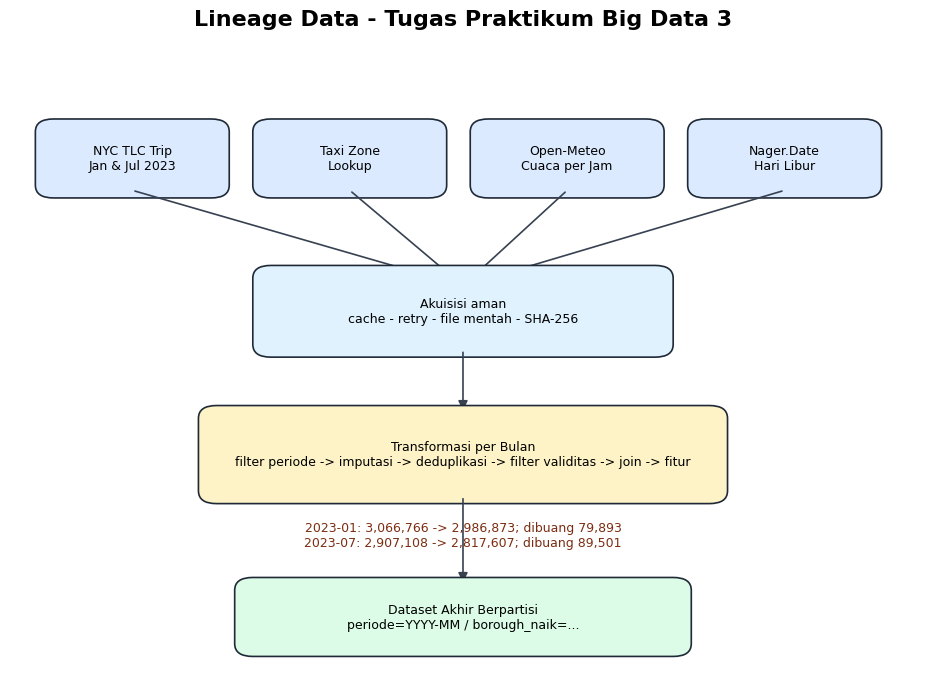

In [76]:
lineage_df = pd.DataFrame(lineage_records).drop_duplicates(
    subset=["sumber", "periode", "asal"], keep="last"
)
PATH_LINEAGE = DIR_SIMPAN / "lineage.csv"
lineage_df.to_csv(PATH_LINEAGE, index=False)

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def kotak(ax, x, y, w, h, teks, warna):
    bentuk = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=1.2,
        edgecolor="#1f2937",
        facecolor=warna,
    )
    ax.add_patch(bentuk)
    ax.text(
        x + w / 2, y + h / 2, teks,
        ha="center", va="center", fontsize=9,
        wrap=True,
    )


def panah(ax, x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="-|>", mutation_scale=14,
        linewidth=1.2, color="#374151",
    ))


fig, ax = plt.subplots(figsize=(11.69, 8.27))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title(
    "Lineage Data - Tugas Praktikum Big Data 3",
    fontsize=16, fontweight="bold", pad=18,
)

sumber = [
    (0.04, "NYC TLC Trip\nJan & Jul 2023"),
    (0.28, "Taxi Zone\nLookup"),
    (0.52, "Open-Meteo\nCuaca per Jam"),
    (0.76, "Nager.Date\nHari Libur"),
]
for x, teks in sumber:
    kotak(ax, x, 0.78, 0.19, 0.10, teks, "#dbeafe")
    panah(ax, x + 0.095, 0.78, 0.50, 0.63)

kotak(
    ax, 0.28, 0.53, 0.44, 0.12,
    "Akuisisi aman\ncache - retry - file mentah - SHA-256",
    "#e0f2fe",
)
panah(ax, 0.50, 0.53, 0.50, 0.43)

transformasi = (
    "Transformasi per Bulan\n"
    "filter periode -> imputasi -> deduplikasi -> "
    "filter validitas -> join -> fitur"
)
kotak(ax, 0.22, 0.30, 0.56, 0.13, transformasi, "#fef3c7")

ringkas_buang = []
for bulan in PERIODE:
    meta = metadata_bulan[bulan]
    ringkas_buang.append(
        f"{bulan}: {meta['baris_awal']:,} -> "
        f"{meta['baris_akhir']:,}; dibuang "
        f"{meta['baris_awal'] - meta['baris_akhir']:,}"
    )
ax.text(
    0.50, 0.26, "\n".join(ringkas_buang),
    ha="center", va="top", fontsize=9, color="#7c2d12",
)

panah(ax, 0.50, 0.30, 0.50, 0.16)
kotak(
    ax, 0.26, 0.06, 0.48, 0.10,
    "Dataset Akhir Berpartisi\nperiode=YYYY-MM / borough_naik=...",
    "#dcfce7",
)

PATH_DIAGRAM_PNG = DIR_SIMPAN / "diagram_lineage.png"
PATH_DIAGRAM_PDF = DIR_SIMPAN / "diagram_lineage.pdf"
plt.savefig(PATH_DIAGRAM_PNG, dpi=200, bbox_inches="tight")
plt.savefig(PATH_DIAGRAM_PDF, bbox_inches="tight")
plt.show()

11 Uji Idempotensi dan Reproducibility

In [77]:
def snapshot_berkas(direktori):
    return {
        str(path.relative_to(direktori)): (
            path.stat().st_size,
            path.stat().st_mtime_ns,
        )
        for path in Path(direktori).rglob("*")
        if path.is_file()
    }


sebelum = snapshot_berkas(DIR_OUTPUT)
hasil_kedua = [pipeline_bulan(bulan) for bulan in PERIODE]
sesudah = snapshot_berkas(DIR_OUTPUT)

tidak_berubah = sebelum == sesudah
semua_cache = all(
    item["status"] == "cache" for item in hasil_kedua
)

print("Status pemanggilan kedua:", [
    item["status"] for item in hasil_kedua
])
print("Jumlah berkas sebelum:", len(sebelum))
print("Jumlah berkas sesudah:", len(sesudah))
print("Idempoten:", tidak_berubah and semua_cache)

assert tidak_berubah and semua_cache

[2023-01] cache keluaran ditemukan; proses dilewati
[2023-07] cache keluaran ditemukan; proses dilewati
Status pemanggilan kedua: ['cache', 'cache']
Jumlah berkas sebelum: 18
Jumlah berkas sesudah: 18
Idempoten: True


In [78]:
pd.DataFrame(catatan_kinerja).to_csv(
    DIR_ARTEFAK / "pengukuran_kinerja.csv", index=False
)

lineage_df = pd.DataFrame(lineage_records).drop_duplicates(
    subset=["sumber", "periode", "asal"], keep="last"
)
lineage_df.to_csv(PATH_LINEAGE, index=False)

path_zip = DIR_SIMPAN / "trips_bersih.zip"
# Buat ZIP sementara pada filesystem Google Drive yang sama dengan
# berkas tujuan agar os.replace() tidak memicu Invalid cross-device link.
base_sementara = DIR_SIMPAN / "trips_bersih_sementara"
zip_sementara = Path(str(base_sementara) + ".zip")
if zip_sementara.exists():
    zip_sementara.unlink()

shutil.make_archive(
    str(base_sementara),
    "zip",
    root_dir=DIR_OUTPUT,
)
os.replace(zip_sementara, path_zip)

artefak_wajib = {
    "laporan_kualitas.csv": path_laporan_gabungan,
    "lineage.csv": PATH_LINEAGE,
    "kamus_data.md": PATH_KAMUS,
    "trips_bersih.zip": path_zip,
    "diagram_lineage.png": PATH_DIAGRAM_PNG,
    "diagram_lineage.pdf": PATH_DIAGRAM_PDF,
}

audit_artefak = pd.DataFrame([
    {
        "artefak": nama,
        "tersedia": path.exists(),
        "ukuran_mb": round(path.stat().st_size / 1024**2, 4)
        if path.exists() else np.nan,
        "lokasi": str(path),
    }
    for nama, path in artefak_wajib.items()
])
display(audit_artefak)

if not audit_artefak["tersedia"].all():
    raise FileNotFoundError("Masih ada artefak wajib yang belum dibuat")


,artefak,tersedia,ukuran_mb,lokasi
0,laporan_kualitas.csv,True,0.0009,/content/drive/MyDrive/BigData/Praktikum3/Tuga...
1,lineage.csv,True,0.0015,/content/drive/MyDrive/BigData/Praktikum3/Tuga...
2,kamus_data.md,True,0.0042,/content/drive/MyDrive/BigData/Praktikum3/Tuga...
3,trips_bersih.zip,True,152.9397,/content/drive/MyDrive/BigData/Praktikum3/Tuga...
4,diagram_lineage.png,True,0.1509,/content/drive/MyDrive/BigData/Praktikum3/Tuga...
5,diagram_lineage.pdf,True,0.0268,/content/drive/MyDrive/BigData/Praktikum3/Tuga...
